In [1]:
import sys
sys.path.insert(0, '../lib')

import glob
import os
import pickle
import datetime
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import datasets
import numpy as np
import pandas as pd
import wandb
import scipy
import sklearn.metrics
import torch
import torch.distributions as td

import common_data
import common_plots

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = "retina"

In [3]:
common_plots.setup_plotting()

In [4]:
pd.options.display.max_columns = 300
pd.options.display.max_rows = 350
pd.options.display.max_colwidth = 10000

In [5]:
with open('02_model_perf.pkl', 'rb') as f:
    model_perf = pickle.load(f)

with open('02_model_df.pkl', 'rb') as f:
    df = pickle.load(f)

In [6]:
def compute_metrics(y_pred_probs, y_pred, y_true):
    auprc = sklearn.metrics.average_precision_score(y_true, y_pred_probs)
    f1_binary = sklearn.metrics.f1_score(y_true, y_pred, average='binary')
    roc_auc = sklearn.metrics.roc_auc_score(y_true, y_pred_probs)
    accuracy = sklearn.metrics.accuracy_score(y_true, y_pred)
    recall = sklearn.metrics.recall_score(y_true, y_pred)
    precision = sklearn.metrics.precision_score(y_true, y_pred)

    return {
        'accuracy': accuracy,
        'f1_binary': f1_binary,
        'AUROC': roc_auc,
        'AUPRC': auprc,
        'recall': recall,
        'precision': precision,
    }

# 1. Variation in performance across random initializations

Text(0.5, 1.0, 'Performance variation across 5 random initializations of the models')

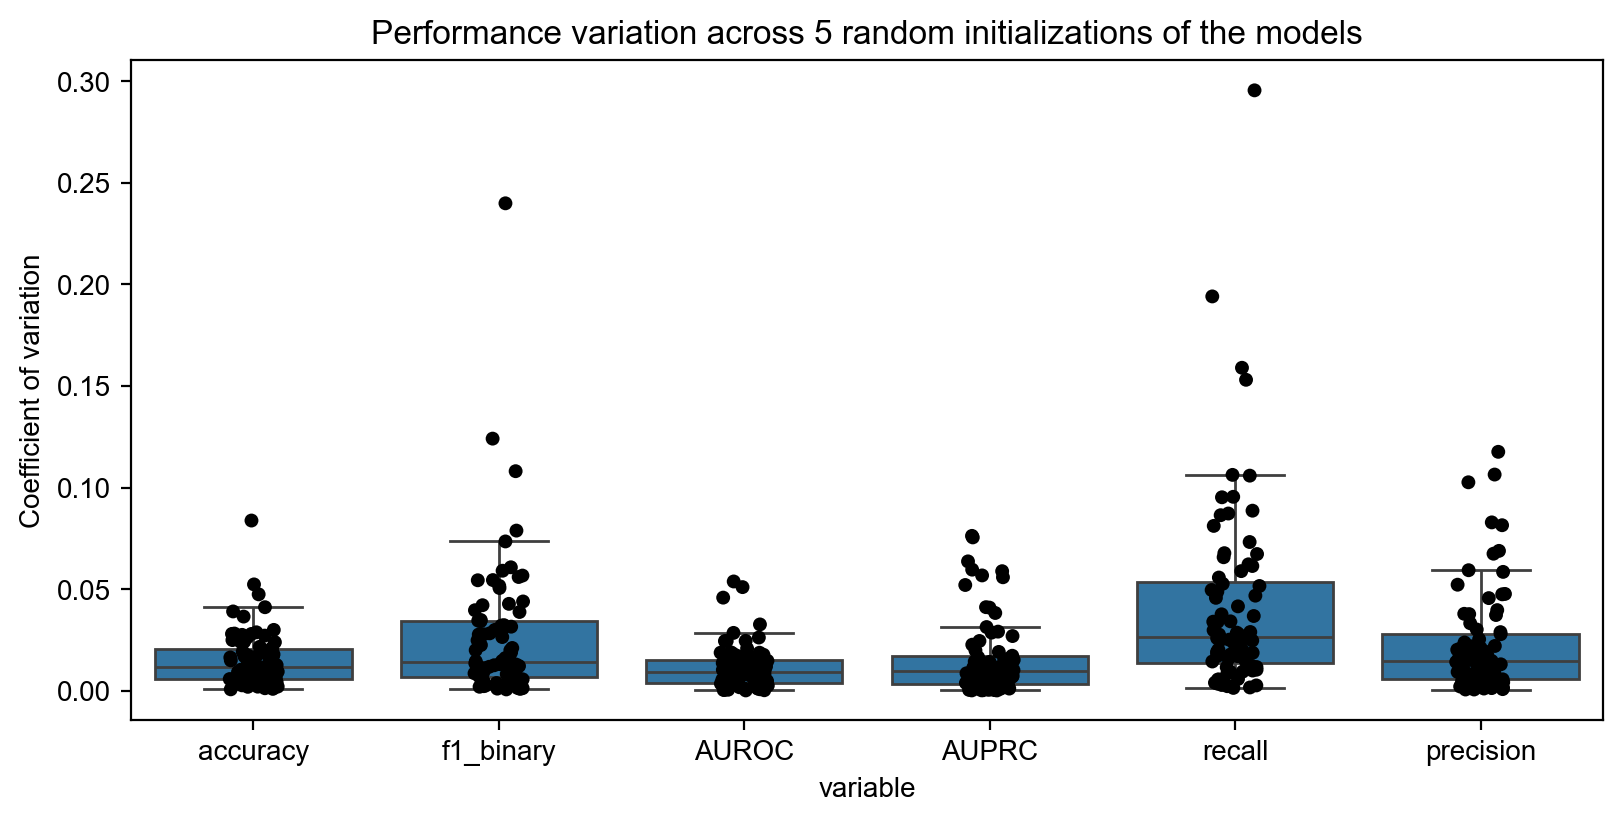

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    sns.boxplot(
        data=(df.groupby(['task', 'split']).std() / df.groupby(['task', 'split']).mean()).melt(ignore_index=False),
        x='variable',
        y='value',
        ax=ax,
        showfliers=False
    )
    sns.stripplot(
        data=(df.groupby(['task', 'split']).std() / df.groupby(['task', 'split']).mean()).melt(ignore_index=False),
        x='variable',
        y='value',
        ax=ax,
        palette=['k']
    )
ax.set_ylabel('Coefficient of variation')
ax.set_title('Performance variation across 5 random initializations of the models')

Text(0.5, 1.0, 'Performance variation across 5 random initializations of the models')

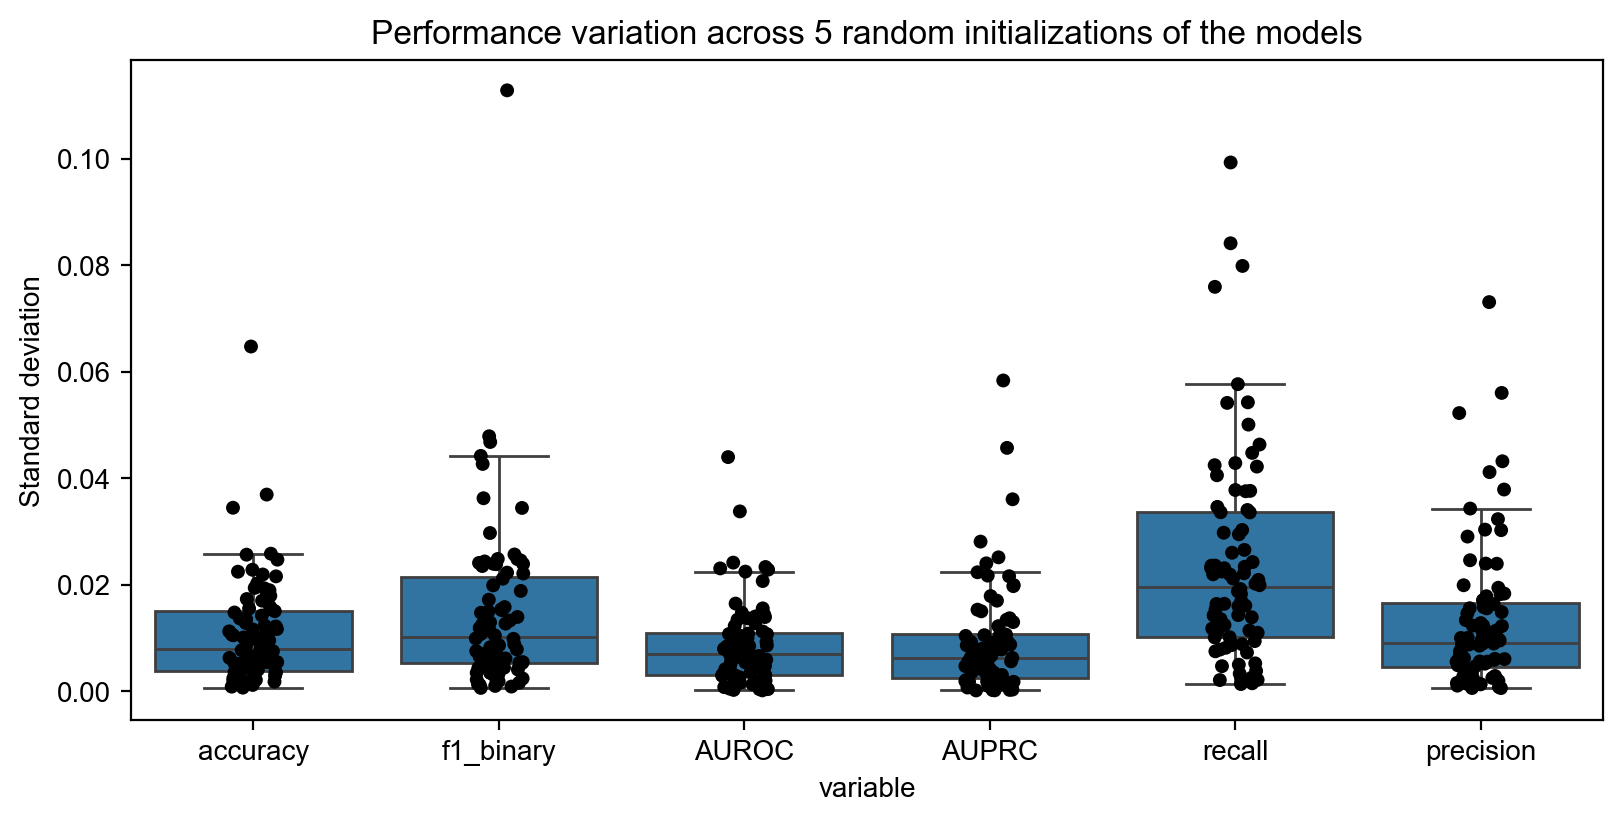

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    sns.boxplot(
        data=(df.groupby(['task', 'split']).std()).melt(ignore_index=False),
        x='variable',
        y='value',
        ax=ax,
        showfliers=False
    )
    sns.stripplot(
        data=(df.groupby(['task', 'split']).std()).melt(ignore_index=False),
        x='variable',
        y='value',
        ax=ax,
        palette=['k']
    )
ax.set_ylabel('Standard deviation')
ax.set_title('Performance variation across 5 random initializations of the models')

# 2. Cell type level predictions

We want:

- heatmap of metrics for cell types across tasks
- average across the 5 random initializations

In [9]:
all_cell_types = set()
for model_df in model_perf.values():
    all_cell_types |= set(model_df.cell_types.unique())

In [10]:
%%time

per_ct_data = []
for model_path, model_df in model_perf.items():
    for cell_type in all_cell_types:
        n_cells_0 = (model_df.cell_types.eq(cell_type) & model_df.true_label.eq(0)).sum()
        n_cells_1 = (model_df.cell_types.eq(cell_type) & model_df.true_label.eq(1)).sum()
        ct_info = dict(
            model_path=model_path,
            cell_type=cell_type,
            n_cells_0=n_cells_0,
            n_cells_1=n_cells_1
        )
        if n_cells_0 > 10 and n_cells_1 > 10:
            idx = model_df.cell_types.eq(cell_type)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                metrics = compute_metrics(model_df.pos_class_prob[idx], model_df.pred_label[idx], model_df.true_label[idx])
            ct_info.update(metrics)
            ct_info['entropy'] = np.mean(model_df.entropy[idx])
        per_ct_data.append(ct_info)

CPU times: user 2min 12s, sys: 258 ms, total: 2min 12s
Wall time: 2min 12s


In [11]:
per_ct_data = pd.DataFrame(per_ct_data)

In [12]:
per_ct_data['model'] = per_ct_data.model_path.str.split('/').str[-1]
per_ct_data['split'] = per_ct_data.model_path.str.split('/').str[-2]
per_ct_data['task'] = per_ct_data.model_path.str.split('/').str[-3]
per_ct_data = per_ct_data.drop(columns='model_path')

In [13]:
per_ct_data = per_ct_data.dropna()

Check that number of cells is equal for different random initializations

In [14]:
assert np.all(per_ct_data.groupby(['cell_type', 'split', 'task']).n_cells_0.std() == 0)
assert np.all(per_ct_data.groupby(['cell_type', 'split', 'task']).n_cells_1.std() == 0)

Take average across random initializations

In [15]:
per_ct_data_agg = per_ct_data.groupby(['cell_type', 'split', 'task']).mean().reset_index()

/tmp/ipykernel_536250/3970142363.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_ct_data_agg = per_ct_data.groupby(['cell_type', 'split', 'task']).mean().reset_index()


Take average across splits

In [16]:
per_ct_data_agg = per_ct_data_agg.groupby(['cell_type', 'task']).mean().reset_index()

/tmp/ipykernel_536250/2876087149.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_ct_data_agg = per_ct_data_agg.groupby(['cell_type', 'task']).mean().reset_index()


In [17]:
per_ct_data_agg.cell_type = per_ct_data_agg.cell_type.replace({
    'Perivascular macrophages': 'Interstitial macrophages'
})

In [18]:
per_ct_data_agg

,cell_type,task,n_cells_0,n_cells_1,accuracy,f1_binary,AUROC,AUPRC,recall,precision,entropy
0,AT1 and AT2,N_vs_G+,139.00,295.000000,0.524819,0.471164,0.515175,0.534640,0.721624,0.540419,0.951498
1,AT1 and AT2,N_vs_G-,141.00,18.000000,0.815319,0.161722,0.698211,0.422163,0.100000,0.466667,0.783559
2,AT1 and AT2,N_vs_P_COVID,21.00,17.000000,0.552632,0.452967,0.570308,0.541035,0.423529,0.499091,0.966468
3,AT1 and AT2,N_vs_eCOVID,83.75,91.750000,0.519379,0.393618,0.579831,0.709802,0.280112,0.750037,0.811224
4,AT1 and AT2,N_vs_eCOVID_G+,21.00,66.000000,0.268966,0.068459,0.693074,0.869625,0.036364,0.800000,0.630585
...,...,...,...,...,...,...,...,...,...,...,...
440,pDC,N_vs_eCOVID_G+,43.00,131.500000,0.772194,0.818967,0.693241,0.871671,0.792944,0.873701,0.841124
441,pDC,N_vs_lCOVID,40.00,149.333333,0.632816,0.719959,0.511660,0.691099,0.764915,0.684479,0.897947
442,pDC,N_vs_lCOVID_G+,43.00,60.000000,0.566973,0.662628,0.463141,0.577569,0.772917,0.596987,0.863412
443,pDC,is_episode_cured,64.00,50.000000,0.473456,0.497431,0.497311,0.457179,0.671017,0.434118,0.924709


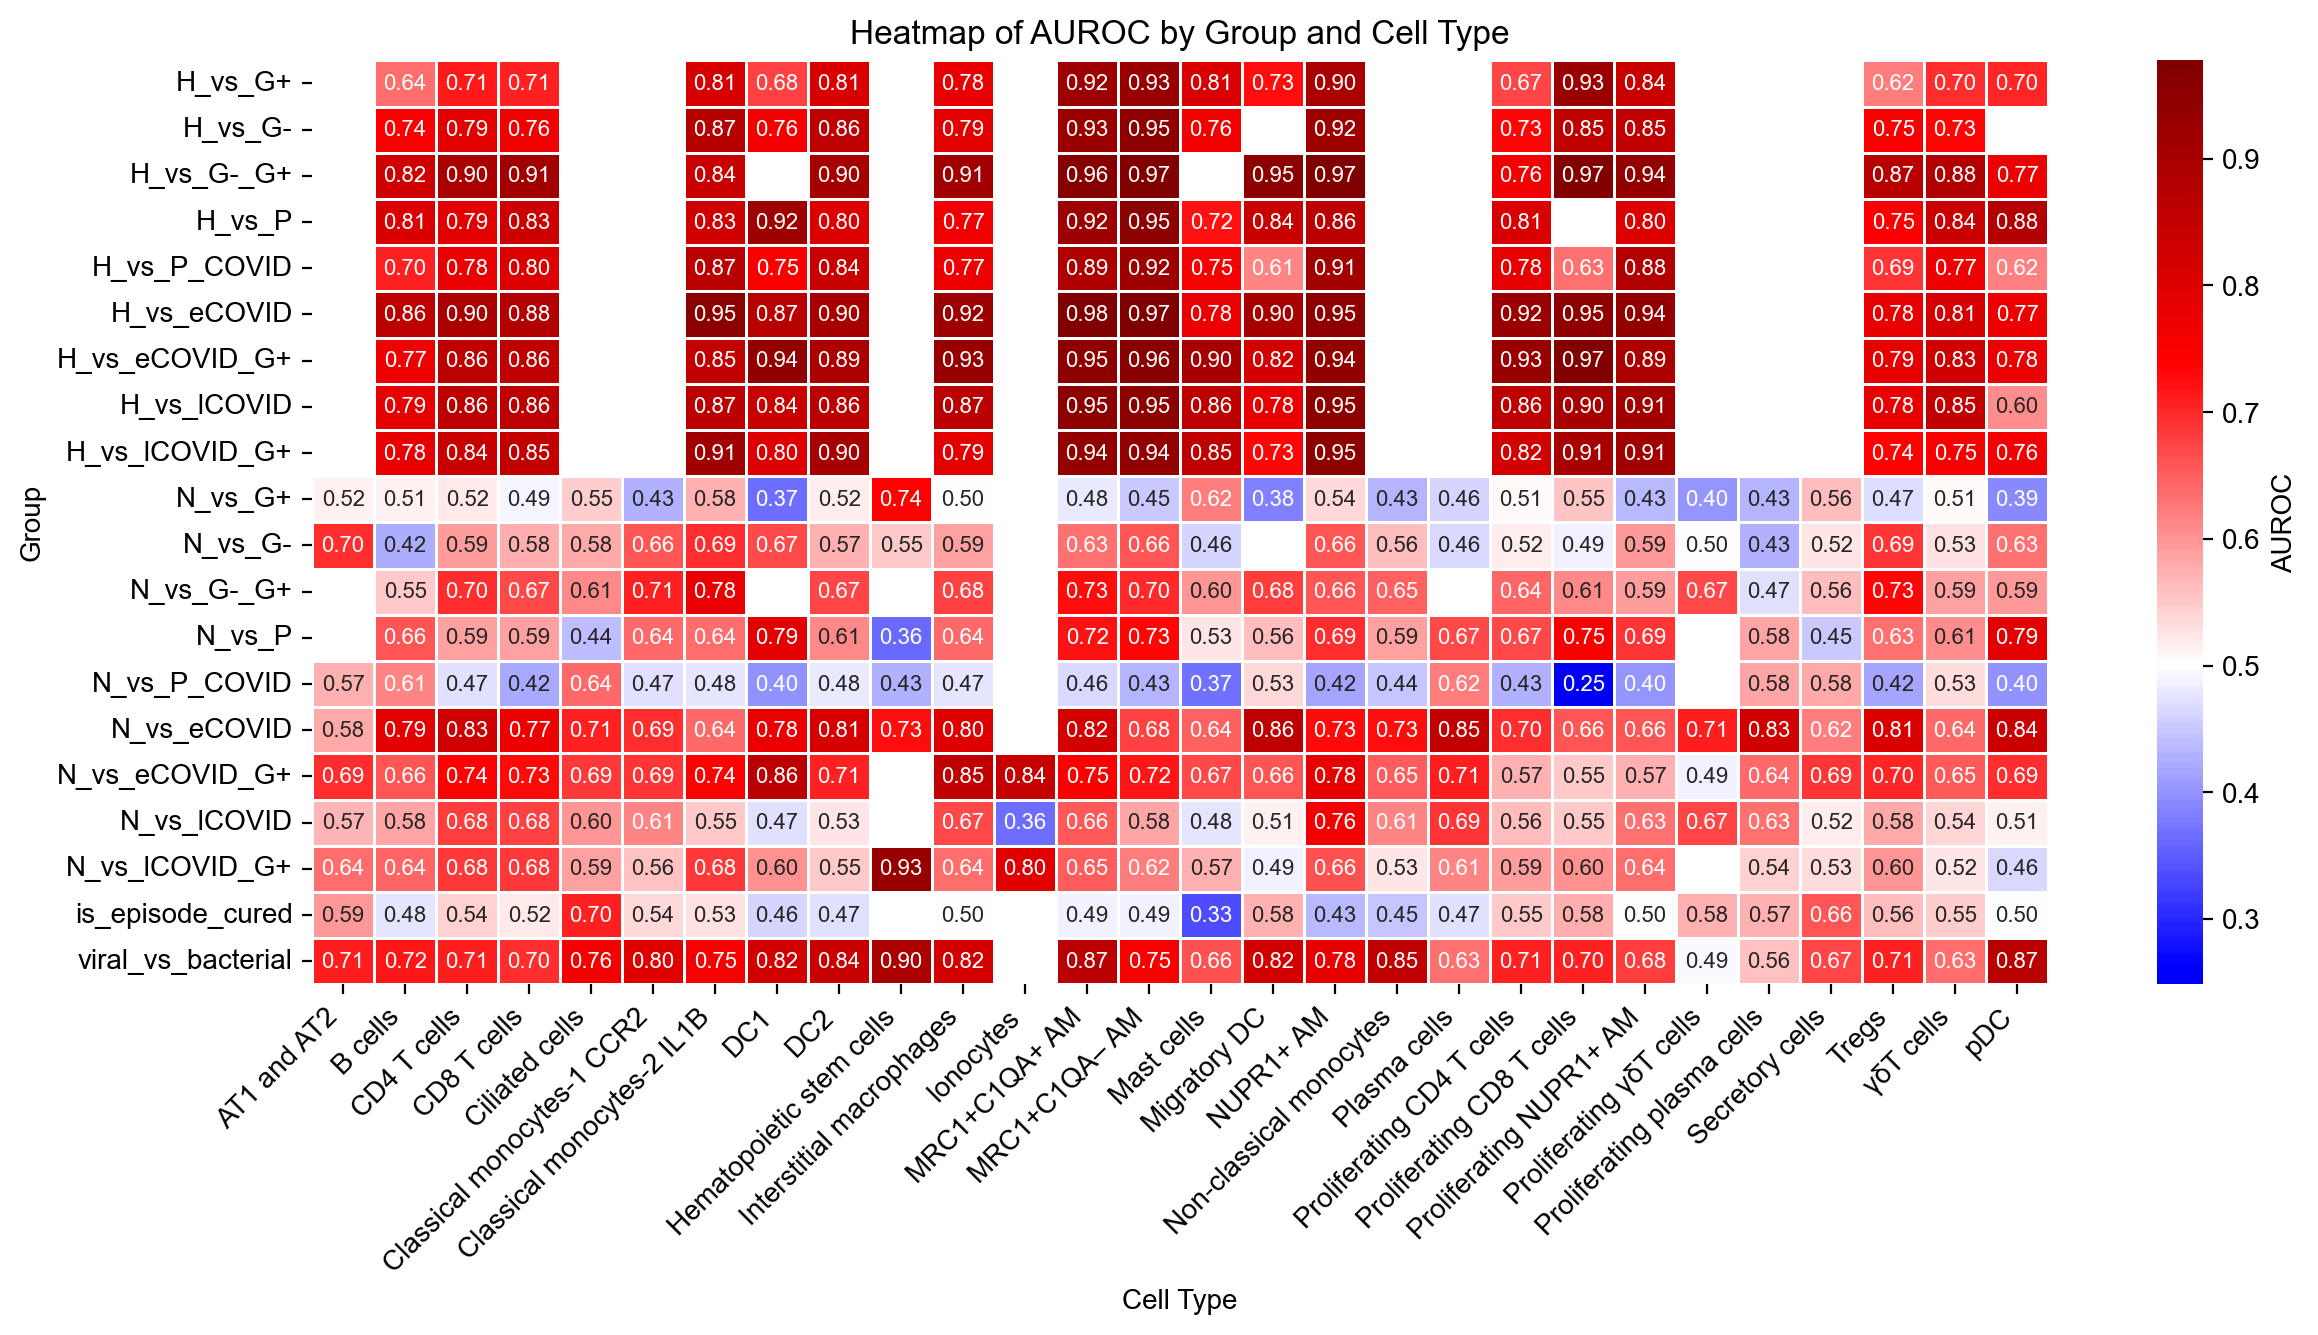

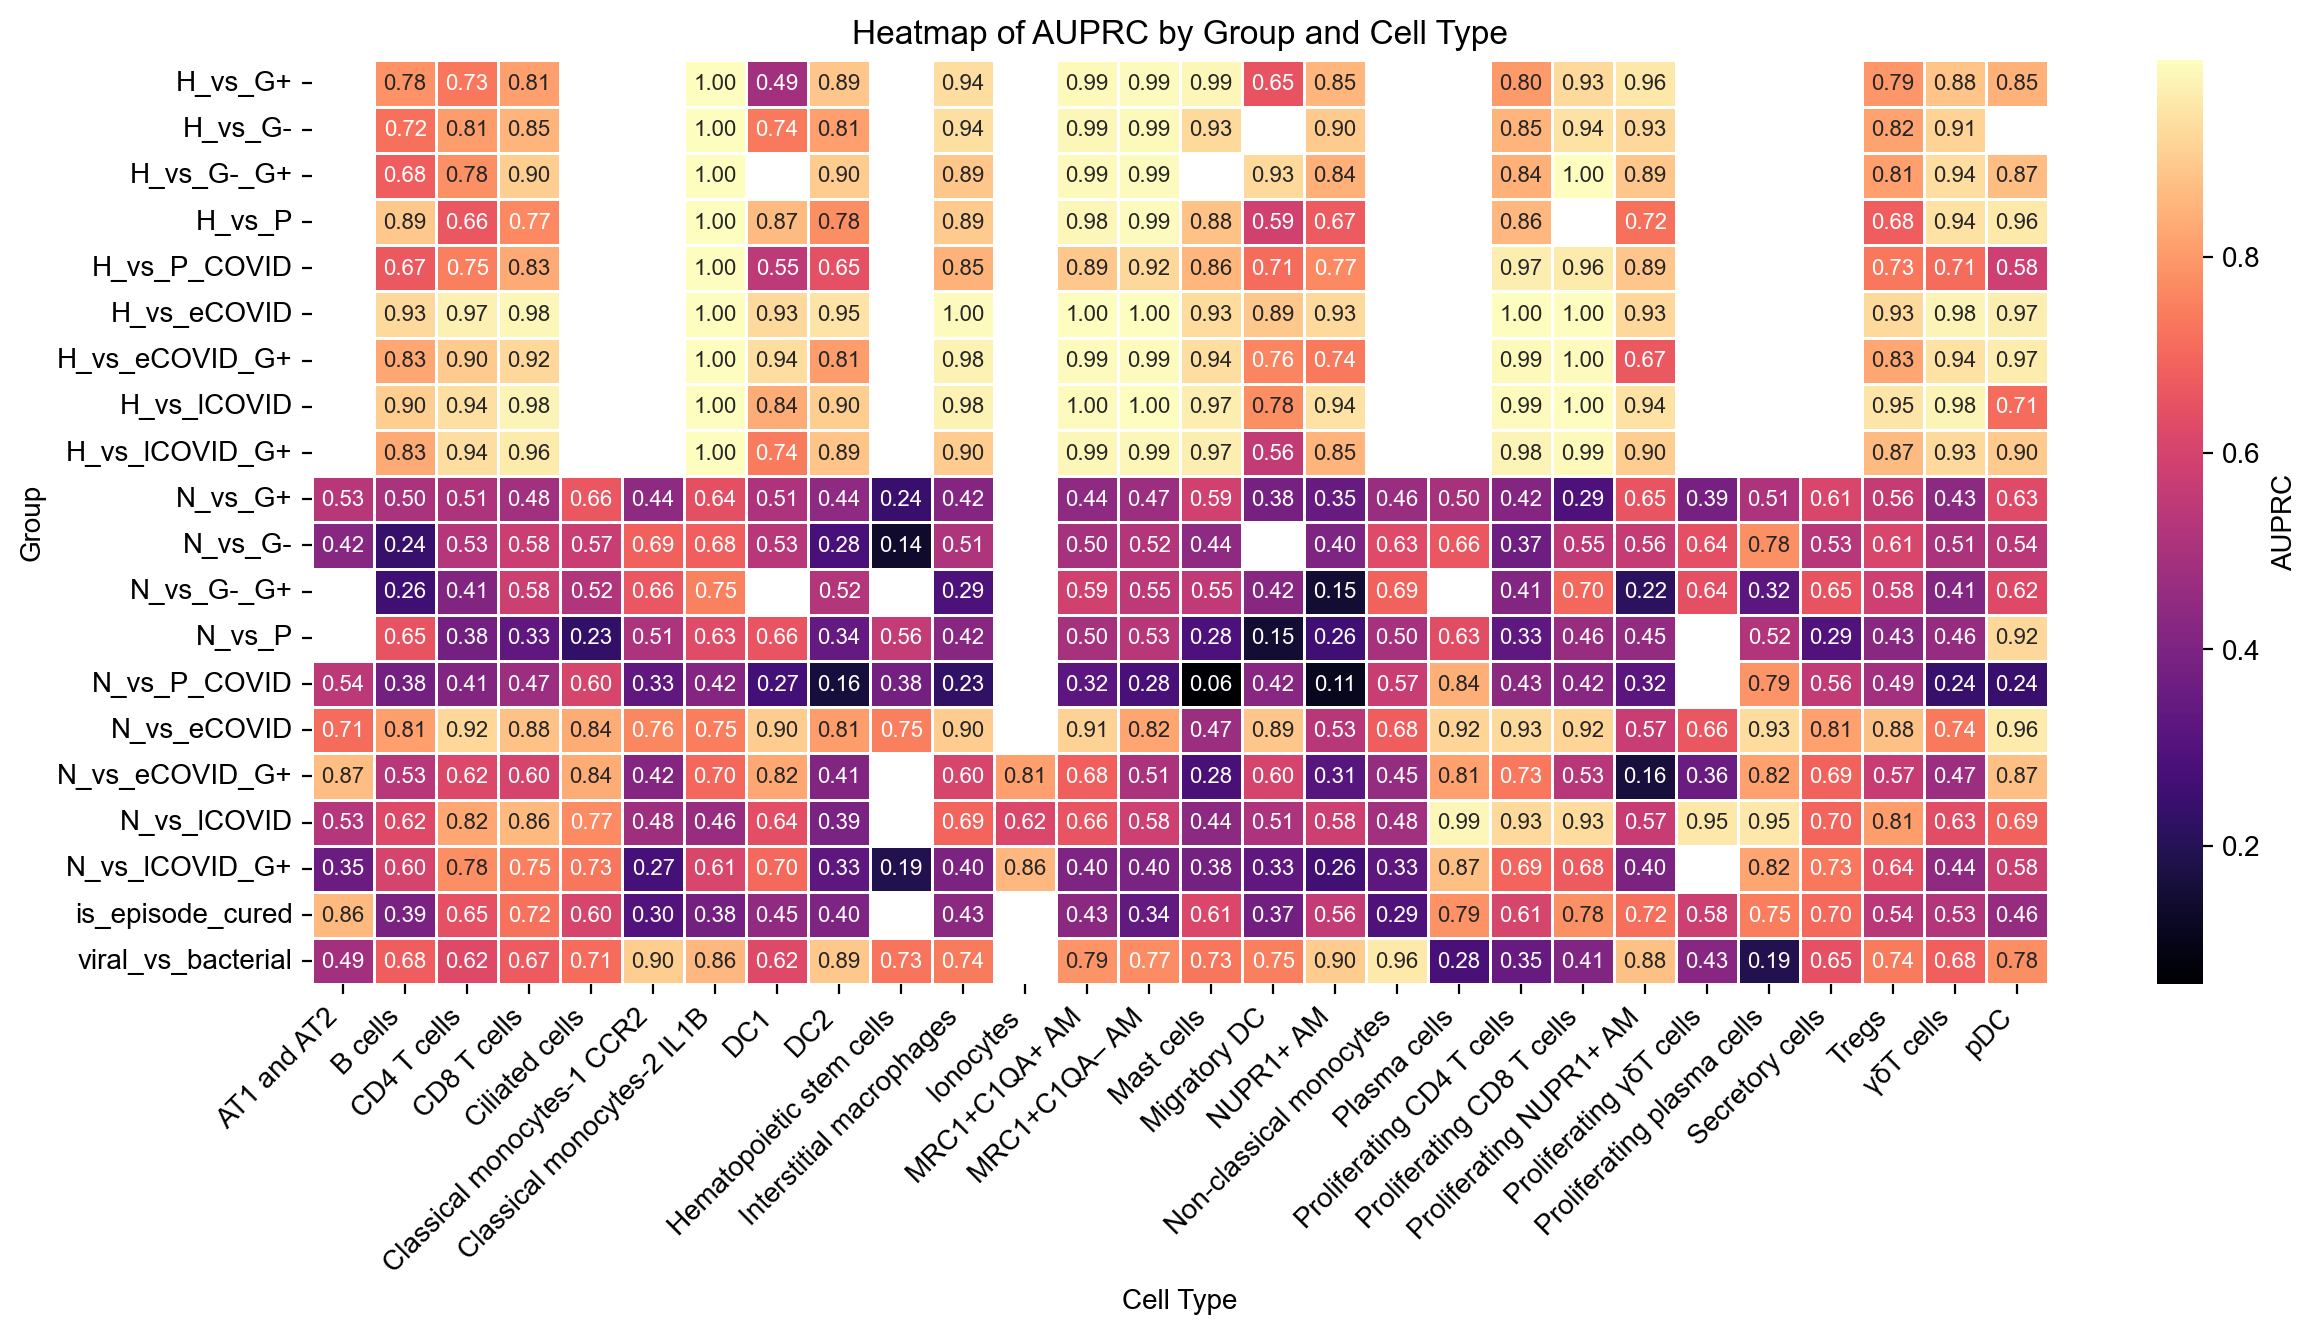

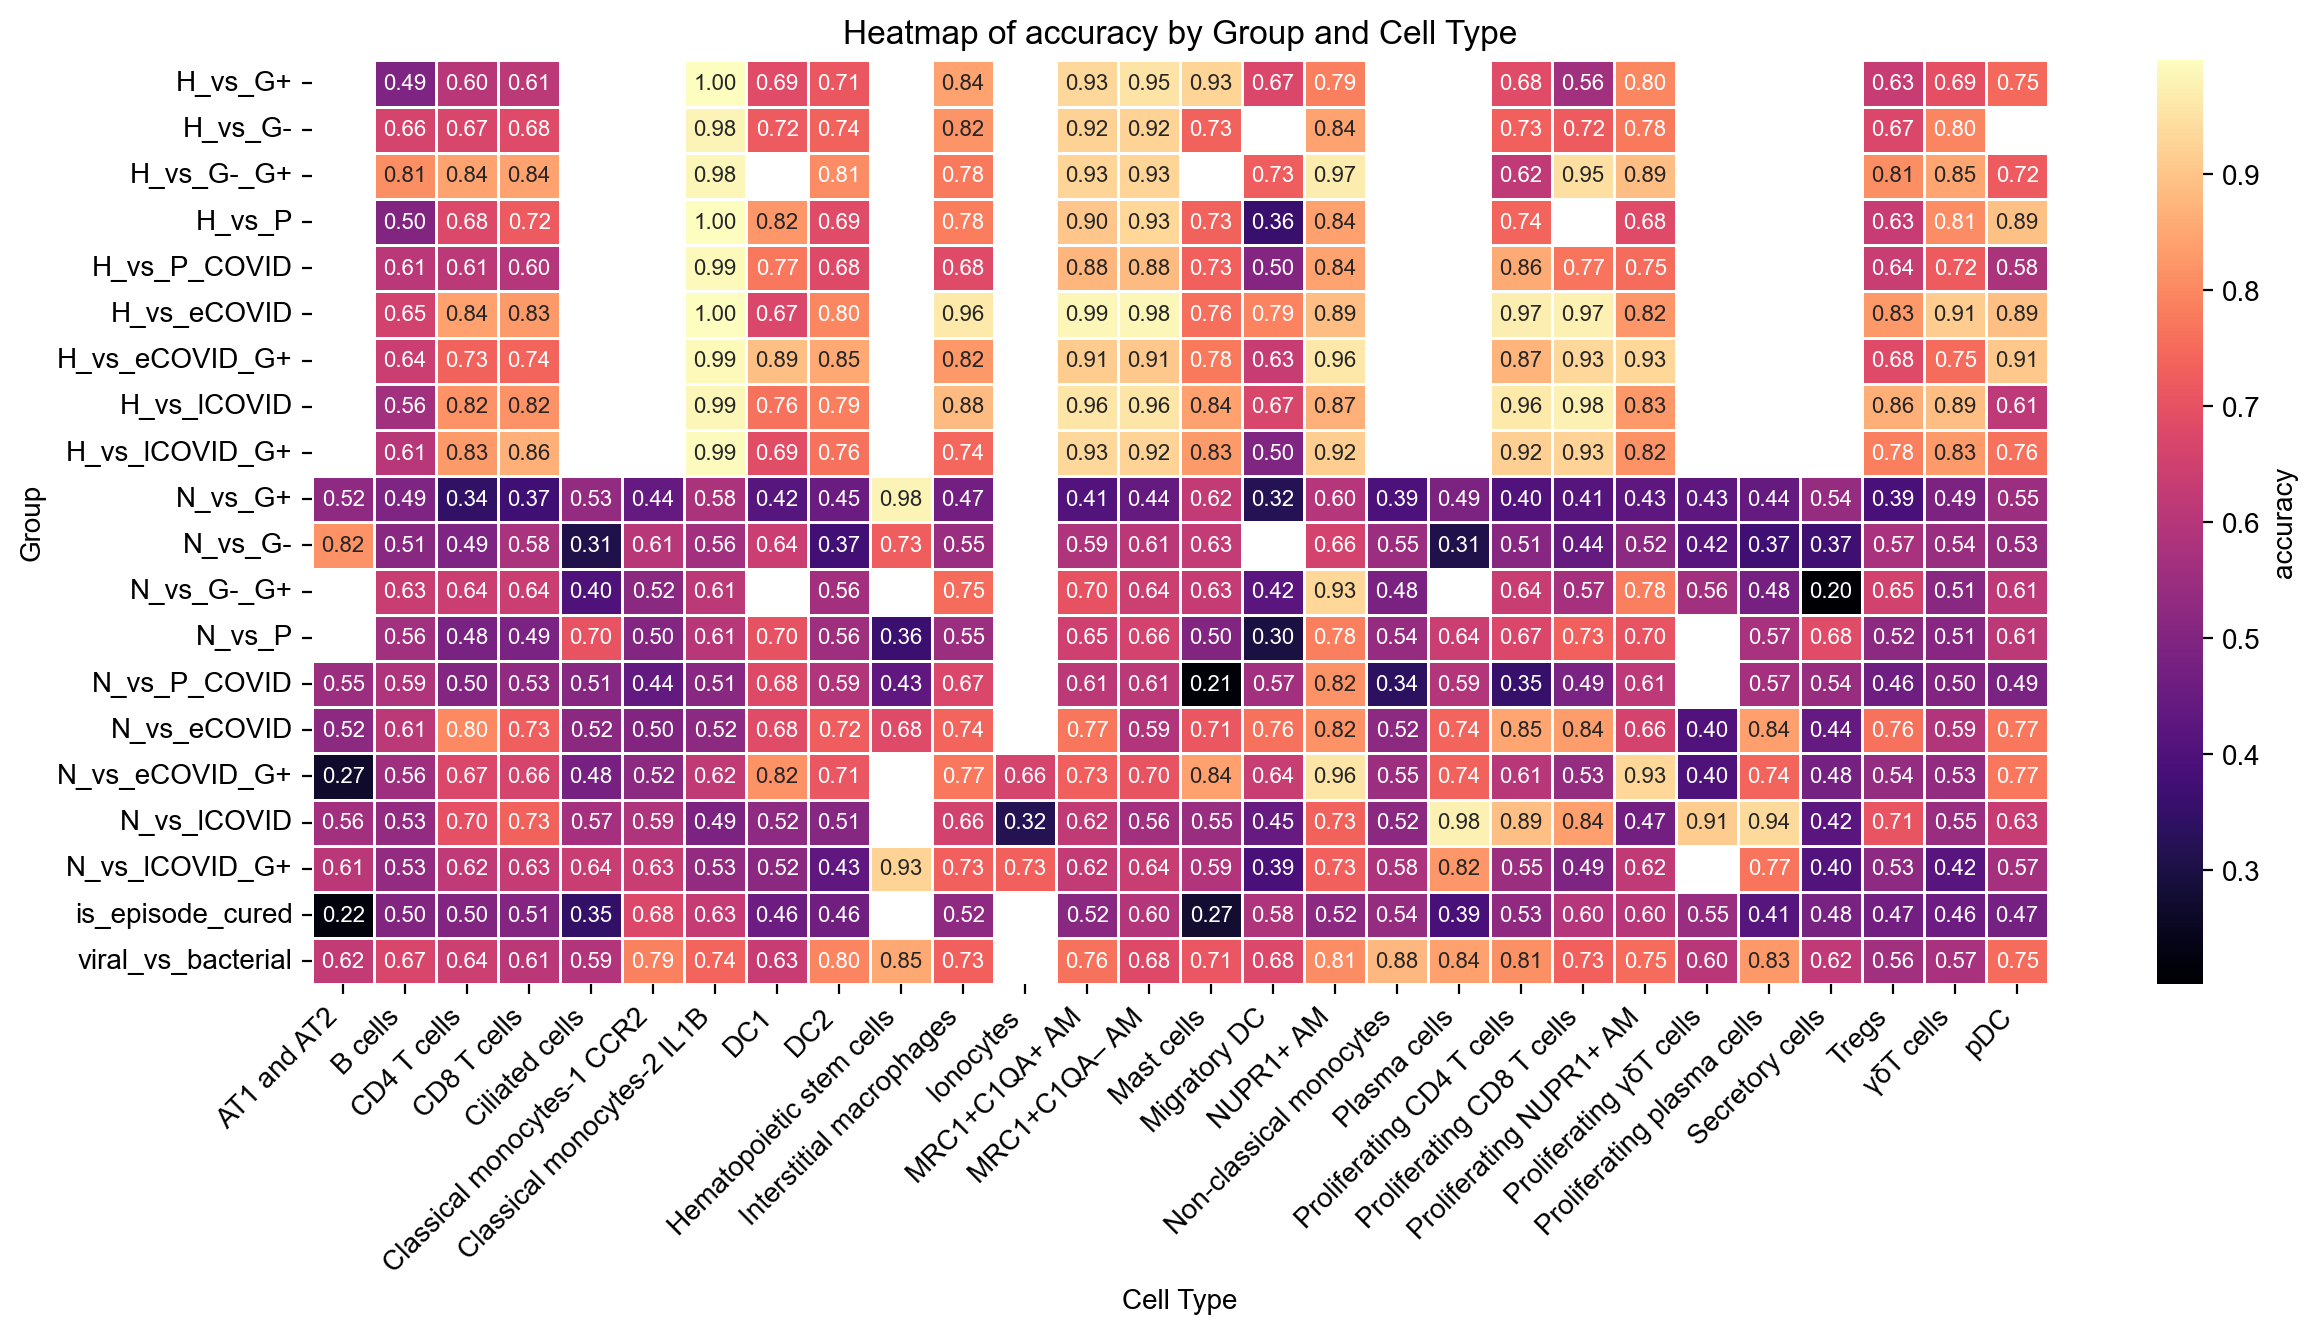

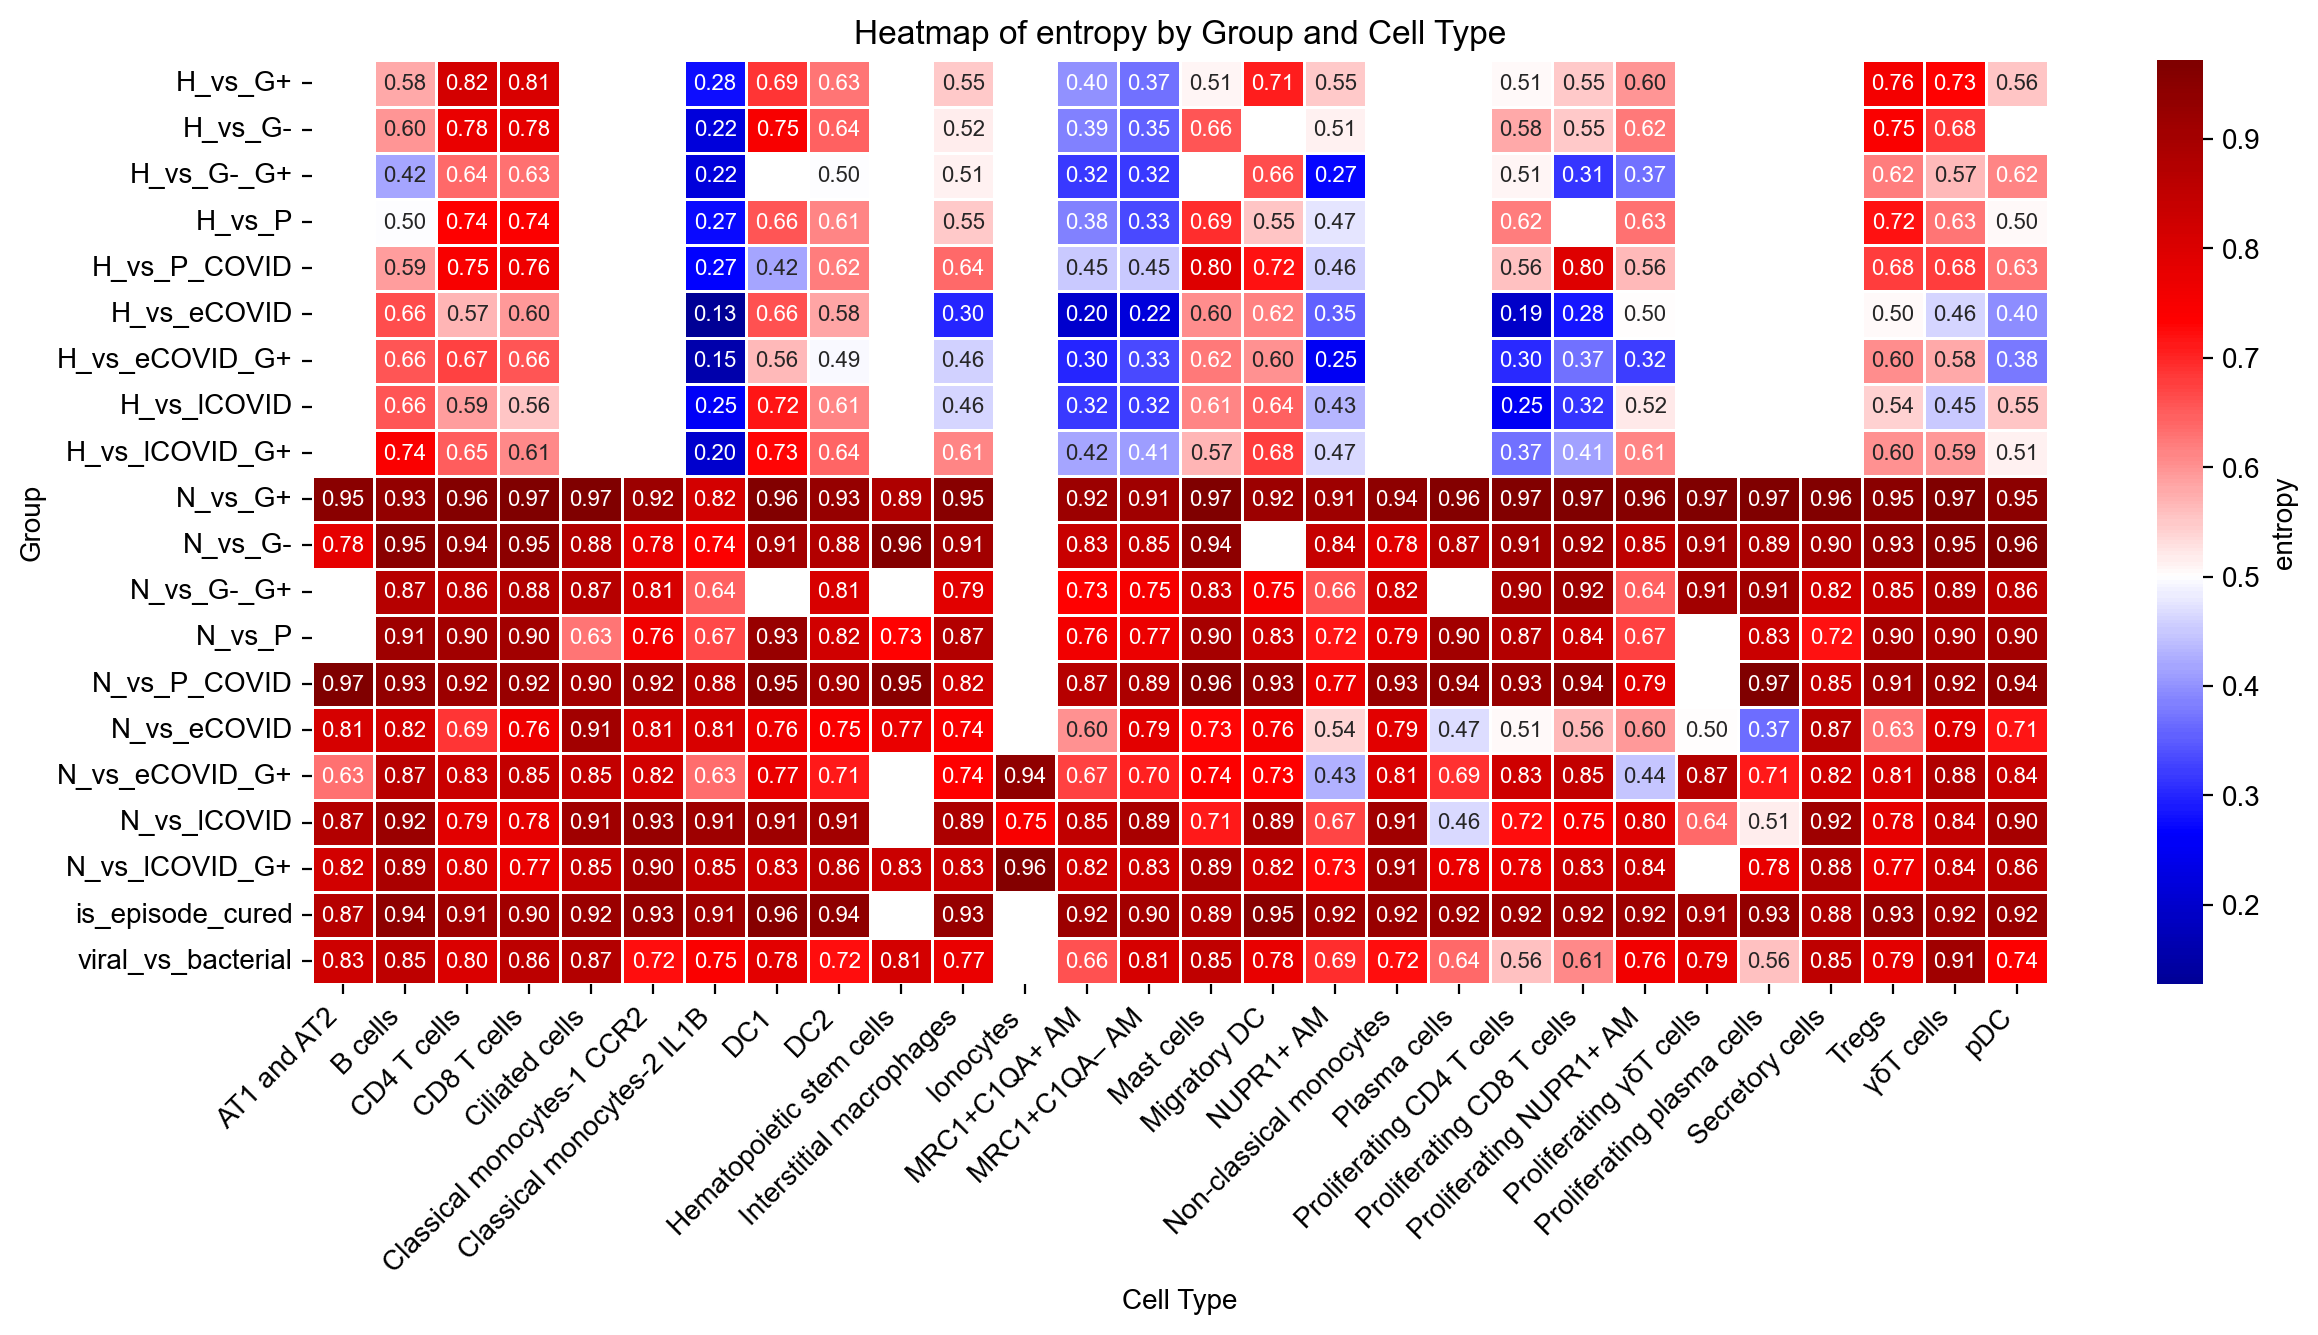

In [19]:
# List of numeric columns to create heatmaps for
numeric_columns = ['AUROC', 'AUPRC', 'accuracy', 'entropy']

# Create a heatmap for each numeric column
for column in numeric_columns:
    # Pivot the dataframe to create a 2D matrix
    pivot_data = per_ct_data_agg.pivot(index='task', columns='cell_type', values=column)
    pivot_data.columns = pd.Series(pivot_data.columns).replace(common_plots.CELL_TYPES_DISPLAY)

    # Create a mask for NaN values
    mask = pivot_data.isnull()

    # Create a new figure
    fig, ax = plt.subplots(figsize=(14, 6))

    # Generate the heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        cmap=column in ('AUROC', 'entropy') and 'seismic' or 'magma',
        fmt='.2f',
        annot_kws={
            'size': 8
        },
        cbar_kws={'label': column},
        mask=mask,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        center=column in ('AUROC', 'entropy') and 0.5 or None
    )

    # Set the title and labels
    ax.set_title(f'Heatmap of {column} by Group and Cell Type')
    ax.set_xlabel('Cell Type')
    ax.set_ylabel('Group')

    # Rotate x-axis labels for better readability if needed
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.show()

In [20]:
CELL_TYPE_ORDER = [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'DC2',
    'Classical monocytes-2 IL1B',
    'Interstitial macrophages',
    'Proliferating NUPR1+ Macs',

    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'Tregs',
    'Proliferating CD4 T cells',
    'Proliferating CD8 T cells',

    'B cells',
]

In [21]:
TASKS_MAP = {
    'H_vs_G+': 'Healthy vs. Gram+',
    'H_vs_G-': 'Healthy vs. Other Gram–',
    'H_vs_G-_G+': 'Healthy vs. Other Gram–; Gram+',
    'H_vs_P': 'Healthy vs. Pseudomonas',
    'H_vs_P_COVID': 'Healthy vs. SARS-CoV-2; Pseudomonas',
    'H_vs_eCOVID': 'Healthy vs. Early SARS-CoV-2',
    'H_vs_eCOVID_G+': 'Healthy vs. Early SARS-CoV-2; Gram+',
    'H_vs_lCOVID': 'Healthy vs. Late SARS-CoV-2',
    'H_vs_lCOVID_G+': 'Healthy vs. Late SARS-CoV-2; Gram+',
    'N_vs_G+': 'NPC vs. Gram+',
    'N_vs_G-': 'NPC vs. Other Gram–',
    'N_vs_G-_G+': 'NPC vs. Other Gram–; Gram+',
    'N_vs_P': 'NPC vs. Pseudomonas',
    'N_vs_P_COVID': 'NPC vs. SARS-CoV-2; Pseudomonas',
    'N_vs_eCOVID': 'NPC vs. Early SARS-CoV-2',
    'N_vs_eCOVID_G+': 'NPC vs. Early SARS-CoV-2; Gram+',
    'N_vs_lCOVID': 'NPC vs. Late SARS-CoV-2',
    'N_vs_lCOVID_G+': 'NPC vs. Late SARS-CoV-2; Gram+',
    'is_episode_cured': 'VAP cured by day 7',
    'viral_vs_bacterial': 'Early SARS-CoV-2 vs. Bacteria only'
}

In [22]:
TASK_ORDER = [
    'H_vs_eCOVID',
    'H_vs_lCOVID',
    'H_vs_G+',
    'H_vs_P',
    'H_vs_G-',
    'H_vs_G-_G+',
    'H_vs_eCOVID_G+',
    'H_vs_lCOVID_G+',
    'H_vs_P_COVID',

    'N_vs_eCOVID',
    'N_vs_lCOVID',
    'N_vs_G+',
    'N_vs_P',
    'N_vs_G-',
    'N_vs_G-_G+',
    'N_vs_eCOVID_G+',
    'N_vs_lCOVID_G+',
    'N_vs_P_COVID',

    'viral_vs_bacterial',
    'is_episode_cured',
]

/tmp/ipykernel_536250/2188335775.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_536250/2188335775.py:65: UserWarning: 
The palette list has fewer values (1) than needed (14) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


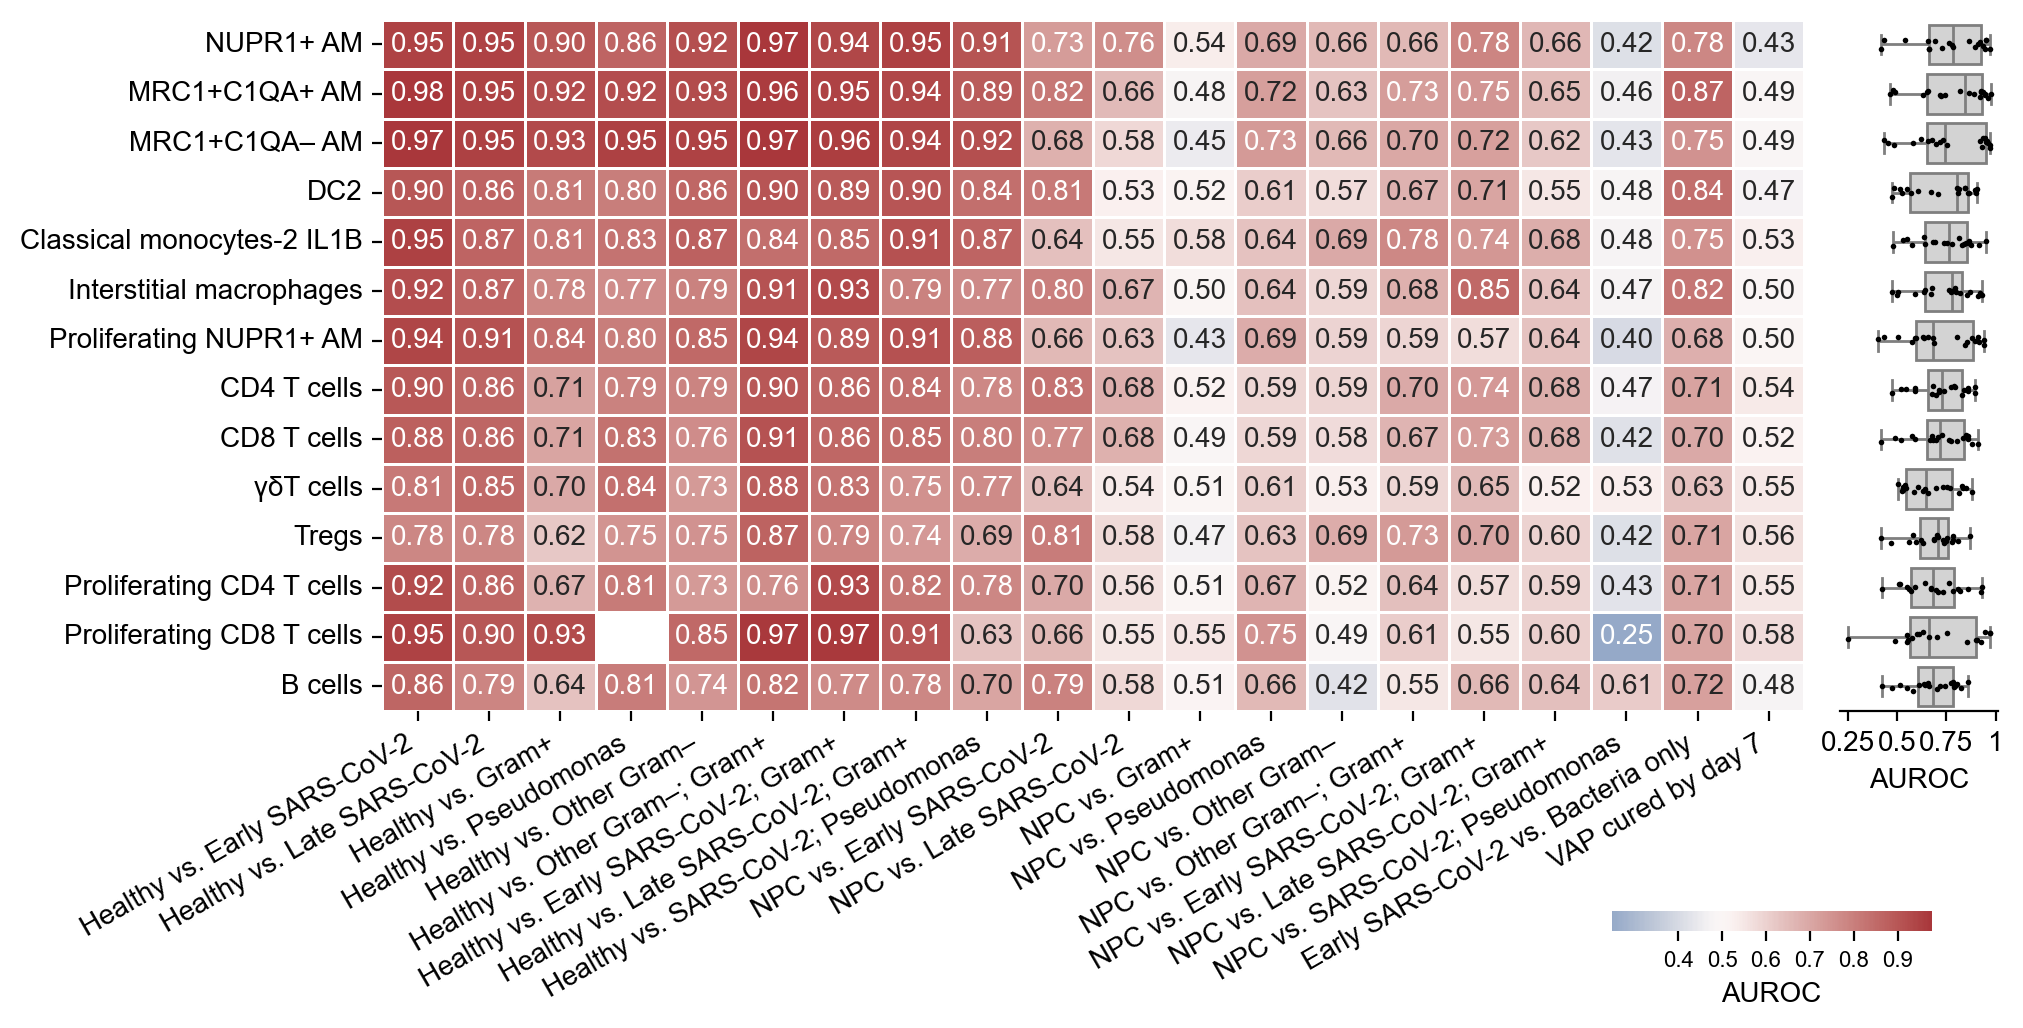

In [23]:
# Pivot the dataframe to create a 2D matrix
pivot_data = per_ct_data_agg.pivot(index='task', columns='cell_type', values='AUROC')
pivot_data.drop(columns=[
    'AT1 and AT2', 'Ciliated cells', 'Hematopoietic stem cells',
    'Ionocytes', 'Non-classical monocytes', 'Secretory cells',
    'Plasma cells', 'Proliferating plasma cells', 'Proliferating gdT cells',
    'Mast cells', 'Migratory DC', 'Classical monocytes-1 CCR2',
], inplace=True)
pivot_data = pivot_data[CELL_TYPE_ORDER]
pivot_data = pivot_data.loc[TASK_ORDER]
pivot_data.index = pd.Series(pivot_data.index).replace(TASKS_MAP)
pivot_data.columns = pd.Series(pivot_data.columns).replace(common_plots.CELL_TYPES_DISPLAY)

# Create a mask for NaN values
mask = pivot_data.isnull()

# Create a new figure
fig, axes = plt.subplots(
    figsize=(10, 5),
    constrained_layout=True,
    ncols=2,
    gridspec_kw={'width_ratios': [0.9, 0.1], 'wspace': 0},
    sharey=True,
)

ax = axes[0]

cbar_ax = fig.add_axes((0.8, 0.08, 0.16, 0.02))

# Generate the heatmap
sns.heatmap(
    pivot_data.T,
    annot=True,
    cmap='vlag',
    center=0.5,
    fmt='.2f',
    mask=mask.T,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='AUROC',
        orientation='horizontal',
        ticks=[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    ),
)

cbar_ax.tick_params(labelsize=8)

# Set the title and labels
# ax.set_title(f'Heatmap of AUROC by Group and Cell Type')
ax.set_xlabel('')
ax.set_ylabel('')

# Rotate x-axis labels for better readability if needed
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=30, ha='right');

ax = axes[1]
boxplot_data = pivot_data.melt()
boxplot_data['cell_type_idx'] = pd.Categorical(
    boxplot_data['cell_type'],
    categories=pd.Series(CELL_TYPE_ORDER).replace(common_plots.CELL_TYPES_DISPLAY)
).codes + 0.5
sns.boxplot(
    data=boxplot_data,
    orient='h',
    x='value',
    y='cell_type_idx',
    ax=ax,
    native_scale=True,
    palette=['lightgray']
)
sns.stripplot(
    data=boxplot_data,
    orient='h',
    x='value',
    y='cell_type_idx',
    ax=ax,
    native_scale=True,
    size=2,
    color='k'
)
ax.yaxis.set_visible(False)
ax.set_xlabel('AUROC')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_xticks([0.25, 0.5, 0.75, 1.0], labels=['0.25', '0.5', '0.75', '1'])
fig.savefig('00_plots/02b_auroc_heatmap.pdf')

### 2.1 Healthy tasks only

In [24]:
TASK_ORDER = [
    'H_vs_eCOVID',
    'H_vs_lCOVID',
    'H_vs_G+',
    'H_vs_P',
    'H_vs_G-',
    'H_vs_G-_G+',
    'H_vs_eCOVID_G+',
    'H_vs_lCOVID_G+',
    'H_vs_P_COVID',
]

/tmp/ipykernel_536250/2827991231.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_536250/2827991231.py:67: UserWarning: 
The palette list has fewer values (1) than needed (14) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


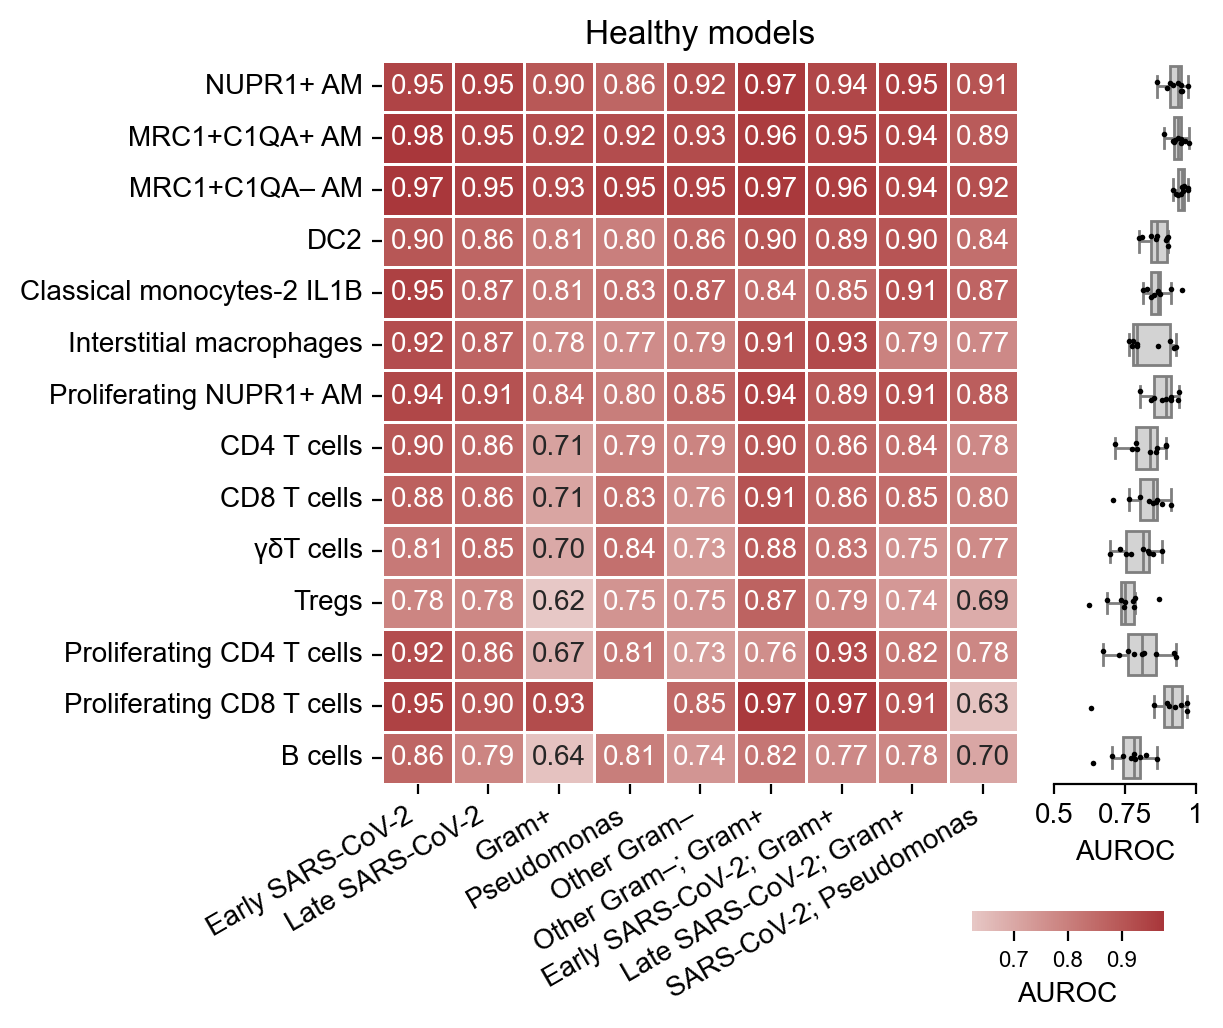

In [25]:
# Pivot the dataframe to create a 2D matrix
pivot_data = per_ct_data_agg.pivot(index='task', columns='cell_type', values='AUROC')
pivot_data.drop(columns=[
    'AT1 and AT2', 'Ciliated cells', 'Hematopoietic stem cells',
    'Ionocytes', 'Non-classical monocytes', 'Secretory cells',
    'Plasma cells', 'Proliferating plasma cells', 'Proliferating gdT cells',
    'Mast cells', 'Migratory DC', 'Classical monocytes-1 CCR2',
], inplace=True)
pivot_data = pivot_data[CELL_TYPE_ORDER]
pivot_data = pivot_data.loc[TASK_ORDER]
pivot_data.index = pd.Series(pivot_data.index).replace(TASKS_MAP)
pivot_data.columns = pd.Series(pivot_data.columns).replace(common_plots.CELL_TYPES_DISPLAY)

# Create a mask for NaN values
mask = pivot_data.isnull()

# Create a new figure
fig, axes = plt.subplots(
    figsize=(6, 5),
    constrained_layout=True,
    ncols=2,
    gridspec_kw={'width_ratios': [0.9, 0.2], 'wspace': 0},
    sharey=True,
)

ax = axes[0]

cbar_ax = fig.add_axes((0.8, 0.08, 0.16, 0.02))

# Generate the heatmap
sns.heatmap(
    pivot_data.T,
    annot=True,
    cmap='vlag',
    center=0.5,
    fmt='.2f',
    mask=mask.T,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='AUROC',
        orientation='horizontal',
        ticks=[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    ),
)

cbar_ax.tick_params(labelsize=8)

# Set the title and labels
# ax.set_title(f'Heatmap of AUROC by Group and Cell Type')
ax.set_xlabel('')
ax.set_ylabel('')

# Rotate x-axis labels for better readability if needed
ax.set_xticklabels(labels=[x.get_text().replace('Healthy vs. ', '') for x in ax.get_xticklabels()], rotation=30, ha='right');

ax.set_title('Healthy models')

ax = axes[1]
boxplot_data = pivot_data.melt()
boxplot_data['cell_type_idx'] = pd.Categorical(
    boxplot_data['cell_type'],
    categories=pd.Series(CELL_TYPE_ORDER).replace(common_plots.CELL_TYPES_DISPLAY)
).codes + 0.5
sns.boxplot(
    data=boxplot_data,
    orient='h',
    x='value',
    y='cell_type_idx',
    ax=ax,
    native_scale=True,
    palette=['lightgray'],
    showfliers=False
)
sns.stripplot(
    data=boxplot_data,
    orient='h',
    x='value',
    y='cell_type_idx',
    ax=ax,
    native_scale=True,
    size=2,
    color='k'
)
ax.yaxis.set_visible(False)
ax.set_xlabel('AUROC')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_xlim(0.5, 1)
ax.set_xticks([0.5, 0.75, 1.0], labels=['0.5', '0.75', '1'])
fig.savefig('00_plots/02b_auroc_heatmap_healthy.pdf')

### 2.2 NPC tasks only

In [26]:
TASK_ORDER = [
    'N_vs_eCOVID',
    'N_vs_lCOVID',
    'N_vs_G+',
    'N_vs_P',
    'N_vs_G-',
    'N_vs_G-_G+',
    'N_vs_eCOVID_G+',
    'N_vs_lCOVID_G+',
    'N_vs_P_COVID',
]

/tmp/ipykernel_536250/3457675506.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_536250/3457675506.py:67: UserWarning: 
The palette list has fewer values (1) than needed (14) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


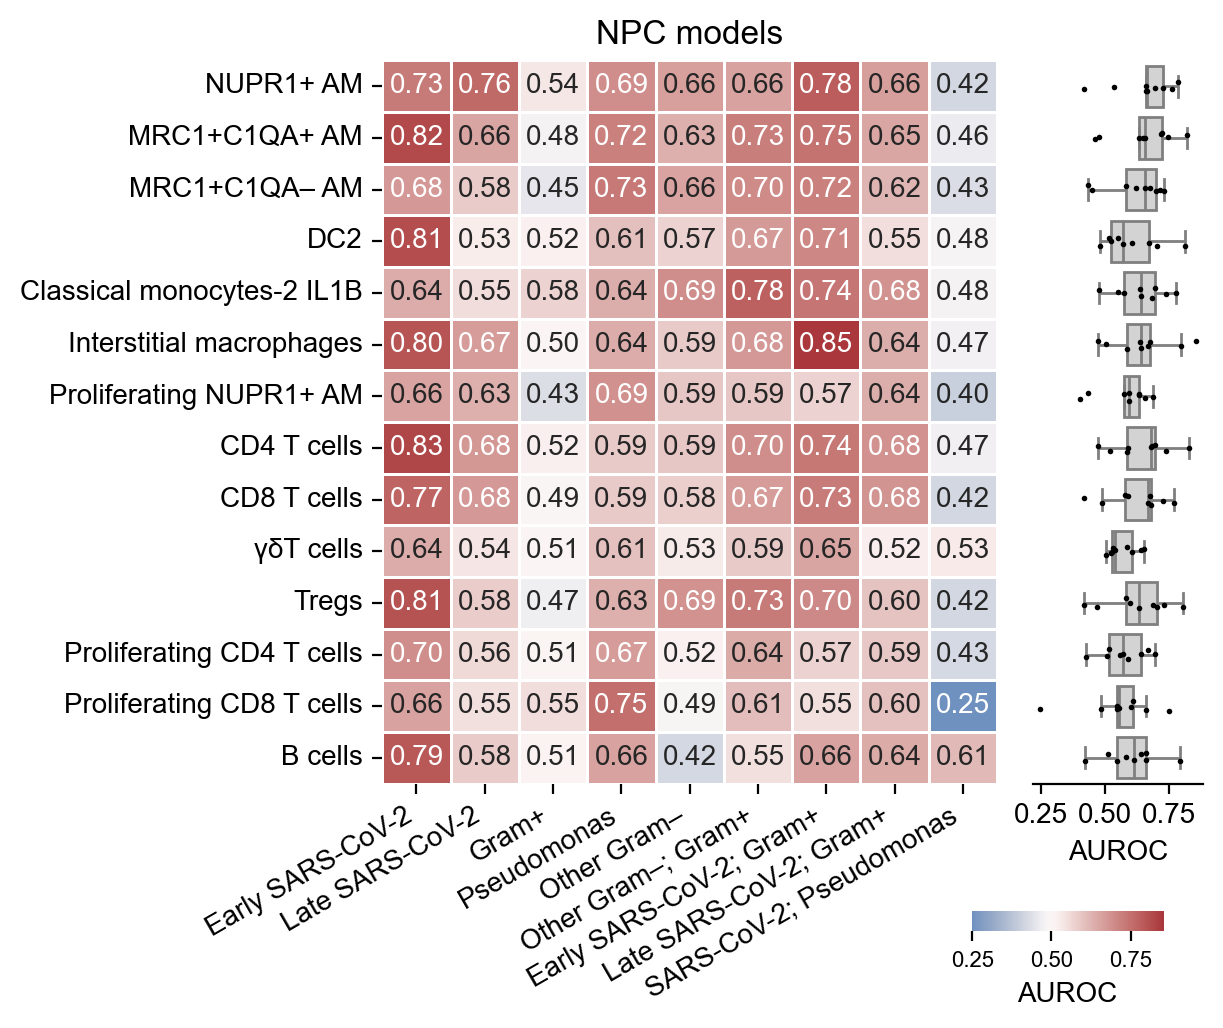

In [27]:
# Pivot the dataframe to create a 2D matrix
pivot_data = per_ct_data_agg.pivot(index='task', columns='cell_type', values='AUROC')
pivot_data.drop(columns=[
    'AT1 and AT2', 'Ciliated cells', 'Hematopoietic stem cells',
    'Ionocytes', 'Non-classical monocytes', 'Secretory cells',
    'Plasma cells', 'Proliferating plasma cells', 'Proliferating gdT cells',
    'Mast cells', 'Migratory DC', 'Classical monocytes-1 CCR2',
], inplace=True)
pivot_data = pivot_data[CELL_TYPE_ORDER]
pivot_data = pivot_data.loc[TASK_ORDER]
pivot_data.index = pd.Series(pivot_data.index).replace(TASKS_MAP)
pivot_data.columns = pd.Series(pivot_data.columns).replace(common_plots.CELL_TYPES_DISPLAY)

# Create a mask for NaN values
mask = pivot_data.isnull()

# Create a new figure
fig, axes = plt.subplots(
    figsize=(6, 5),
    constrained_layout=True,
    ncols=2,
    gridspec_kw={'width_ratios': [0.9, 0.25], 'wspace': 0},
    sharey=True,
)

ax = axes[0]

cbar_ax = fig.add_axes((0.8, 0.08, 0.16, 0.02))

# Generate the heatmap
sns.heatmap(
    pivot_data.T,
    annot=True,
    cmap='vlag',
    center=0.5,
    fmt='.2f',
    mask=mask.T,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='AUROC',
        orientation='horizontal',
        # ticks=[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    ),
)

cbar_ax.tick_params(labelsize=8)

# Set the title and labels
# ax.set_title(f'Heatmap of AUROC by Group and Cell Type')
ax.set_xlabel('')
ax.set_ylabel('')

# Rotate x-axis labels for better readability if needed
ax.set_xticklabels(labels=[x.get_text().replace('NPC vs. ', '') for x in ax.get_xticklabels()], rotation=30, ha='right');

ax.set_title('NPC models')

ax = axes[1]
boxplot_data = pivot_data.melt()
boxplot_data['cell_type_idx'] = pd.Categorical(
    boxplot_data['cell_type'],
    categories=pd.Series(CELL_TYPE_ORDER).replace(common_plots.CELL_TYPES_DISPLAY)
).codes + 0.5
sns.boxplot(
    data=boxplot_data,
    orient='h',
    x='value',
    y='cell_type_idx',
    ax=ax,
    native_scale=True,
    palette=['lightgray'],
    showfliers=False
)
sns.stripplot(
    data=boxplot_data,
    orient='h',
    x='value',
    y='cell_type_idx',
    ax=ax,
    native_scale=True,
    size=2,
    color='k'
)
ax.yaxis.set_visible(False)
ax.set_xlabel('AUROC')
ax.spines[['top', 'right', 'left']].set_visible(False)
# ax.set_xlim(0.5, 1)
# ax.set_xticks([0.5, 0.75, 1.0], labels=['0.5', '0.75', '1'])
fig.savefig('00_plots/02b_auroc_heatmap_npc.pdf')

### 2.3 Other tasks only, no boxplots

In [28]:
TASK_ORDER = [
    'viral_vs_bacterial',
    'is_episode_cured',
]

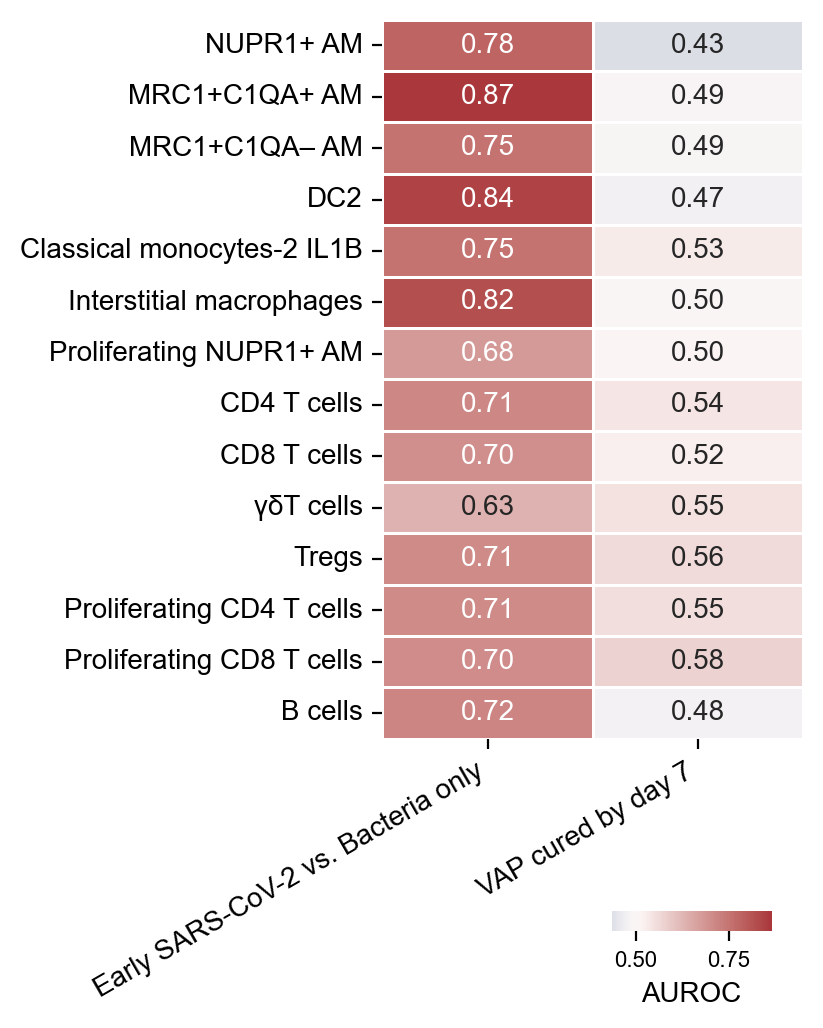

In [29]:
# Pivot the dataframe to create a 2D matrix
pivot_data = per_ct_data_agg.pivot(index='task', columns='cell_type', values='AUROC')
pivot_data.drop(columns=[
    'AT1 and AT2', 'Ciliated cells', 'Hematopoietic stem cells',
    'Ionocytes', 'Non-classical monocytes', 'Secretory cells',
    'Plasma cells', 'Proliferating plasma cells', 'Proliferating gdT cells',
    'Mast cells', 'Migratory DC', 'Classical monocytes-1 CCR2',
], inplace=True)
pivot_data = pivot_data[CELL_TYPE_ORDER]
pivot_data = pivot_data.loc[TASK_ORDER]
pivot_data.index = pd.Series(pivot_data.index).replace(TASKS_MAP)
pivot_data.columns = pd.Series(pivot_data.columns).replace(common_plots.CELL_TYPES_DISPLAY)

# Create a mask for NaN values
mask = pivot_data.isnull()

# Create a new figure
fig, ax = plt.subplots(
    figsize=(4, 5),
    constrained_layout=True,
    ncols=1,
    # gridspec_kw={'width_ratios': [0.9, 0.25], 'wspace': 0},
    # sharey=True,
)

# ax = axes[0]

cbar_ax = fig.add_axes((0.75, 0.08, 0.2, 0.02))

# Generate the heatmap
sns.heatmap(
    pivot_data.T,
    annot=True,
    cmap='vlag',
    center=0.5,
    fmt='.2f',
    mask=mask.T,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='AUROC',
        orientation='horizontal',
        # ticks=[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    ),
)

cbar_ax.tick_params(labelsize=8)

# Set the title and labels
# ax.set_title(f'Heatmap of AUROC by Group and Cell Type')
ax.set_xlabel('')
ax.set_ylabel('')

# Rotate x-axis labels for better readability if needed
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=30, ha='right');

# ax.set_xlim(0.5, 1)
# ax.set_xticks([0.5, 0.75, 1.0], labels=['0.5', '0.75', '1'])
fig.savefig('00_plots/02b_auroc_heatmap_other.pdf')

# 3. Sample level predictions

We want:

- aggregate all predictions per sample as average predictions of all cells
- compute metrics on sample level

In [30]:
TASK_ORDER = [
    'H_vs_eCOVID',
    'H_vs_lCOVID',
    'H_vs_G+',
    'H_vs_P',
    'H_vs_G-',
    'H_vs_G-_G+',
    'H_vs_eCOVID_G+',
    'H_vs_lCOVID_G+',
    'H_vs_P_COVID',

    'N_vs_eCOVID',
    'N_vs_lCOVID',
    'N_vs_G+',
    'N_vs_P',
    'N_vs_G-',
    'N_vs_G-_G+',
    'N_vs_eCOVID_G+',
    'N_vs_lCOVID_G+',
    'N_vs_P_COVID',

    'viral_vs_bacterial',
    'is_episode_cured',
]

In [31]:
per_sample_data = []
for model_path, model_df in model_perf.items():
    for sample in model_df['sample'].unique():
        idx = model_df['sample'].eq(sample)
        assert model_df.true_label[idx].std() == 0
        n_cells = idx.sum()
        sample_info = dict(
            model_path=model_path,
            sample=sample,
            n_cells=n_cells,
            avg_pred=model_df.pred_label[idx].mean(),
            true_label=model_df.true_label[idx].iloc[0]
        )
        per_sample_data.append(sample_info)
per_sample_data = pd.DataFrame(per_sample_data)

In [32]:
per_sample_data['model'] = per_sample_data.model_path.str.split('/').str[-1]
per_sample_data['split'] = per_sample_data.model_path.str.split('/').str[-2]
per_sample_data['task'] = per_sample_data.model_path.str.split('/').str[-3]
per_sample_data = per_sample_data.drop(columns='model_path')

Check that number of cells is equal for different random initializations

In [33]:
assert np.all(per_sample_data.groupby(['sample', 'split', 'task']).n_cells.std() == 0)

Take average across random initializations

In [34]:
per_sample_data_agg = per_sample_data.groupby(['sample', 'split', 'task']).mean().reset_index()

/tmp/ipykernel_536250/775600844.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_sample_data_agg = per_sample_data.groupby(['sample', 'split', 'task']).mean().reset_index()


In [35]:
per_sample_data_agg['pred_label'] = (per_sample_data_agg.avg_pred > 0.5).astype(int)

In [36]:
per_sample_metrics = []
for task in per_sample_data_agg.task.unique():
    for split in per_sample_data_agg.split.unique():
        idx = per_sample_data_agg.task.eq(task) & per_sample_data_agg.split.eq(split)
        info = compute_metrics(
            per_sample_data_agg.avg_pred[idx],
            per_sample_data_agg.pred_label[idx],
            per_sample_data_agg.true_label[idx]
        )
        info['task'] = task
        info['split'] = split
        per_sample_metrics.append(info)

per_sample_metrics = pd.DataFrame(per_sample_metrics)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [37]:
class_freqs = per_sample_data_agg.groupby(['task', 'split', 'true_label']).size().unstack(fill_value=0)

In [38]:
total_samples = per_sample_data_agg.groupby(['task', 'split']).size()

In [39]:
auprc_baseline = class_freqs.iloc[:, 1] / total_samples

In [40]:
auprc_data = per_sample_metrics.melt(id_vars=['task', 'split'], value_vars='AUPRC', value_name='AUPRC')
auroc_data = per_sample_metrics.melt(id_vars=['task', 'split'], value_vars='AUROC', value_name='AUROC')

/tmp/ipykernel_536250/1165188806.py:1: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  auprc_data = per_sample_metrics.melt(id_vars=['task', 'split'], value_vars='AUPRC', value_name='AUPRC')
/tmp/ipykernel_536250/1165188806.py:2: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  auroc_data = per_sample_metrics.melt(id_vars=['task', 'split'], value_vars='AUROC', value_name='AUROC')


In [41]:
average_auprc = auprc_data.groupby('task').AUPRC.mean().reset_index()
average_auprc.columns = ['task', 'avg_auprc']

In [42]:
average_auroc = auroc_data.groupby('task').AUROC.mean().reset_index()
average_auroc.columns = ['task', 'avg_auroc']

In [43]:
for df in (auprc_data, auroc_data, average_auprc, average_auroc):
    df['task'] = pd.Categorical(df.task, categories=TASK_ORDER)
    df.sort_values(['task'], inplace=True)
    df['task'] = df.task.astype(str).replace(TASKS_MAP)

In [44]:
auprc_baseline = auprc_baseline.reset_index(name='val').groupby('task').val.mean()

/tmp/ipykernel_536250/1402312241.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), size = 18)


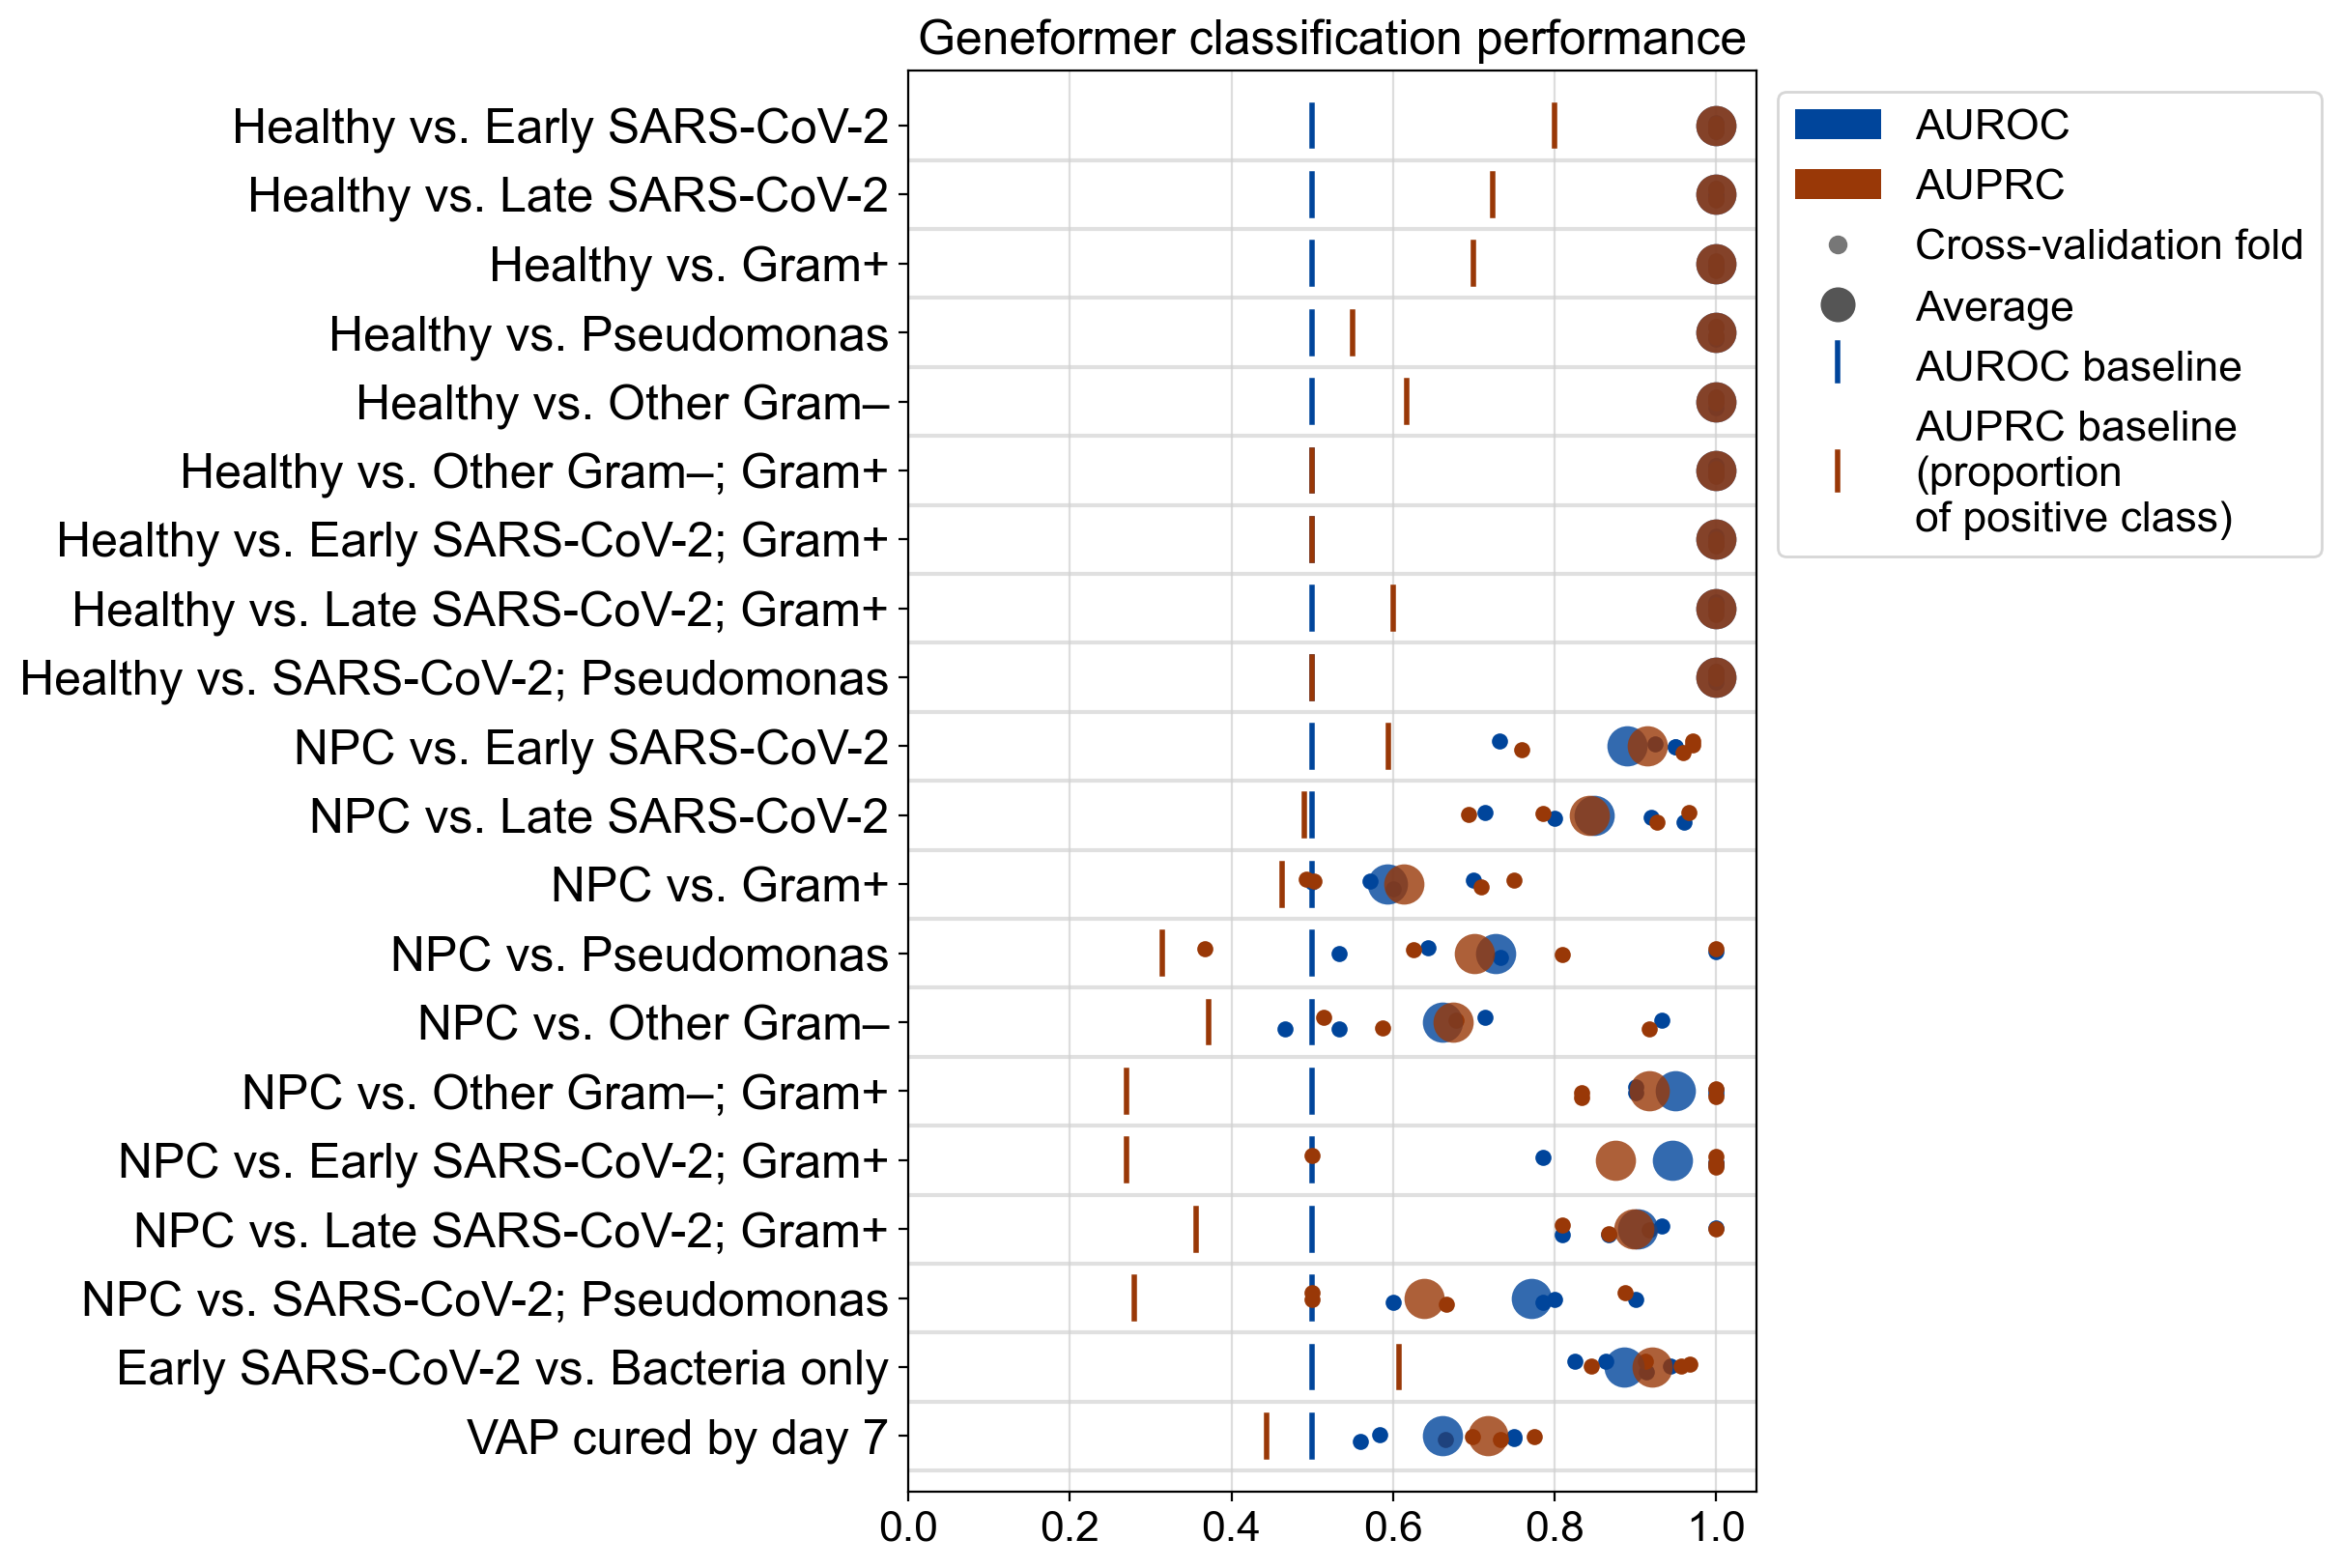

In [45]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)

# Add horizontal lines between Y-axis values
unique_tasks = auprc_data['task'].unique()
for i in range(len(unique_tasks)):
    ax.axhline(y=i + 0.5, color='lightgray', linestyle='-', alpha=0.7)

# Strip plots for AUPRC and AUROC
sns.stripplot(x='AUROC', y='task', data=auroc_data,
              color='#00459b', size=6, dodge=True)
sns.stripplot(x='AUPRC', y='task', data=auprc_data,
              color='#993807', size=6, dodge=True)
sns.stripplot(x='avg_auroc', y='task', data=average_auroc,
              color='#00459b', size=15, alpha=0.8, dodge=True)
sns.stripplot(x='avg_auprc', y='task', data=average_auprc,
              color='#993807', size=15, alpha=0.8, dodge=True)

# Add AUROC baseline markers at 0.5
for i, task in enumerate(unique_tasks):
    ax.plot([0.5, 0.5], [i - 0.3, i + 0.3], color='#00459b', lw=2, ls='-')
    # plt.text(0.5, i, '¦', color='#00459b', ha='center', va='center', fontsize=14)
# Add AUPRC baseline markers at minority frequency
for index, auprc in auprc_baseline.items():
    y_idx = auprc_data.index[auprc_data.task.eq(TASKS_MAP[index])][0]
    y = auprc_data.index.get_loc(y_idx) / 4
    ax.plot(
        [auprc, auprc],
        [y - 0.3, y + 0.3],
        color='#993807', lw=2, ls='-'
    )

# Add legend and labels
ax.set_xlim(0, 1.05)
ax.set_ylim(len(TASK_ORDER) - 0.2, -0.8)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_yticklabels(ax.get_yticklabels(), size = 18)
ax.tick_params(axis='x', labelsize=16)
ax.set_title('Geneformer classification performance', size = 18)
ax.grid(axis='x', color='#ddd')

def update_prop(handle, orig):
    handle.update_from(orig)
    x, y = handle.get_data()
    if orig.get_marker() == 'None':
        handle.set_data([np.mean(x)] * 2, [0, 2.5 * y[0]])

ax.legend(
    [
        mpl.patches.Patch(fc='#00459b'),
        mpl.patches.Patch(fc='#993807'),
        mpl.lines.Line2D(
            [0], [0], marker='o', markersize=6,
            markeredgecolor='#777', markerfacecolor='#777', linestyle=''
        ),
        mpl.lines.Line2D(
            [0], [0], marker='o', markersize=15,
            markeredgecolor='w', markerfacecolor='#555', linestyle='', markeredgewidth=2
        ),
        mpl.lines.Line2D(
            [0], [0], linestyle='-', c='#00459b', lw=2
        ),
        mpl.lines.Line2D(
            [0], [0], linestyle='-', c='#993807', lw=2
        ),
    ],
    [
        'AUROC',
        'AUPRC',
        'Cross-validation fold',
        'Average',
        'AUROC baseline',
        'AUPRC baseline\n(proportion\nof positive class)'
    ],
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fontsize=16,
    handler_map={plt.Line2D: mpl.legend_handler.HandlerLine2D(update_func=update_prop)}
)

fig.savefig('00_plots/02b_sample_metrics.pdf')

In [46]:
per_sample_metrics.task.unique()

array(['viral_vs_bacterial', 'H_vs_G-', 'N_vs_G-', 'H_vs_lCOVID_G+',
       'N_vs_lCOVID_G+', 'H_vs_eCOVID_G+', 'N_vs_eCOVID_G+',
       'H_vs_eCOVID', 'N_vs_eCOVID', 'H_vs_lCOVID', 'N_vs_lCOVID',
       'N_vs_G+', 'N_vs_G-_G+', 'N_vs_P', 'N_vs_P_COVID', 'H_vs_P_COVID',
       'is_episode_cured', 'H_vs_G+', 'H_vs_G-_G+', 'H_vs_P'],
      dtype=object)

In [47]:
per_sample_metrics.AUPRC[per_sample_metrics.task.eq('N_vs_eCOVID_G+')].mean()

0.875

In [48]:
per_sample_metrics.AUPRC[per_sample_metrics.task.eq('viral_vs_bacterial')].mean()

0.9204653259198714

In [53]:
per_sample_metrics.loc[per_sample_metrics.task.eq('is_episode_cured')].agg({'AUROC': 'mean', 'AUPRC': 'mean'})

AUROC    0.660833
AUPRC    0.717798
dtype: float64

Save metrics as supplementary table, reporting random initializations

In [55]:
supp = per_sample_data.groupby(['sample', 'model', 'split', 'task']).mean().reset_index()

In [56]:
supp['pred_label'] = (supp.avg_pred > 0.5).astype(int)

In [ ]:
supp_metrics = []
for task in supp.task.unique():
    for split in supp.split.unique():
        for model in supp.model.unique():
            idx = supp.task.eq(task) & supp.split.eq(split) & supp.model.eq(model)
            info = compute_metrics(
                supp.avg_pred[idx],
                supp.pred_label[idx],
                supp.true_label[idx]
            )
            info['task'] = task
            info['split'] = split
            info['model'] = model
            info['n_negative_cells'] = supp.n_cells[idx & supp.true_label.eq(0)].sum()
            info['n_negative_samples'] = (idx & supp.true_label.eq(0)).sum()
            info['n_positive_cells'] = supp.n_cells[idx & supp.true_label.eq(1)].sum()
            info['n_positive_samples'] = (idx & supp.true_label.eq(1)).sum()

            supp_metrics.append(info)

supp_metrics = pd.DataFrame(supp_metrics)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn

In [101]:
class_freqs = supp.groupby(['task', 'split', 'model', 'true_label']).size().unstack(fill_value=0)

In [102]:
total_samples = supp.groupby(['task', 'split', 'model']).size()

In [103]:
auprc_baseline = class_freqs.iloc[:, 1] / total_samples

In [104]:
supp.shape, supp_metrics.shape, auprc_baseline.shape

((3260, 8), (400, 13), (400,))

In [105]:
supp_metrics = supp_metrics.merge(auprc_baseline.reset_index(), on=['task', 'split', 'model']).rename(columns={0: 'AUPRC_baseline'})

In [106]:
supp_metrics = supp_metrics[[
    'task',
    'split',
    'model',
    'n_negative_cells',
    'n_negative_samples',
    'n_positive_cells',
    'n_positive_samples',
    'AUPRC_baseline',
    'accuracy',
    'precision',
    'recall',
    'f1_binary',
    'AUROC',
    'AUPRC',
]]

In [108]:
supp_metrics.task = pd.Categorical(supp_metrics.task, categories=TASK_ORDER).rename_categories(TASKS_MAP)
supp_metrics = supp_metrics.sort_values(['task', 'split', 'model'])

In [112]:
supp_metrics.task = supp_metrics.task.cat.rename_categories({'Early SARS-CoV-2 vs. Bacteria only': 'Early SARS-CoV-2 vs. Bacterial'})

In [115]:
supp_metrics = supp_metrics.rename(columns={'split': 'data_split'})

In [117]:
supp_metrics.to_csv('00_plots/02b_geneformer_metrics.csv')

# 4. Alternative sample level predictions

We want:

- try 2 strategies of sample level predictions
    - use only specific cell types
    - use all cell types with filter for minimum cells, and vote them equally
- aggregate all predictions per sample as average predictions of all cells
- compute metrics on sample level
- compare new metrics to baseline metrics of just simple averaging

Possibly, other strategies

### Strategy 1, selected cell types

In [29]:
CELL_TYPES_TO_VOTE = [
    'MRC1+C1QA+', 'MRC1+C1QA-', 'CD4 T cells', 'CD8 T cells', 'NUPR1+ Macs'
]

In [30]:
per_sample_data_2 = []
for model_path, model_df in model_perf.items():
    for sample in model_df['sample'].unique():
        idx = model_df['sample'].eq(sample) & model_df.cell_types.isin(CELL_TYPES_TO_VOTE)
        assert model_df.true_label[idx].std() == 0
        n_cells = idx.sum()
        sample_info = dict(
            model_path=model_path,
            sample=sample,
            n_cells=n_cells,
            avg_pred=model_df.pred_label[idx].mean(),
            true_label=model_df.true_label[idx].iloc[0]
        )
        per_sample_data_2.append(sample_info)
per_sample_data_2 = pd.DataFrame(per_sample_data_2)

In [31]:
per_sample_data_2['model'] = per_sample_data_2.model_path.str.split('/').str[-1]
per_sample_data_2['split'] = per_sample_data_2.model_path.str.split('/').str[-2]
per_sample_data_2['task'] = per_sample_data_2.model_path.str.split('/').str[-3]
per_sample_data_2 = per_sample_data_2.drop(columns='model_path')

Check that number of cells is equal for different random initializations

In [32]:
assert np.all(per_sample_data_2.groupby(['sample', 'split', 'task']).n_cells.std() == 0)

Take average across random initializations

In [33]:
per_sample_data_agg_2 = per_sample_data_2.groupby(['sample', 'split', 'task']).mean().reset_index()

/tmp/ipykernel_3295531/481172893.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_sample_data_agg_2 = per_sample_data_2.groupby(['sample', 'split', 'task']).mean().reset_index()


In [34]:
per_sample_data_agg_2['pred_label'] = (per_sample_data_agg_2.avg_pred > 0.5).astype(int)

In [35]:
per_sample_metrics_2 = []
for task in per_sample_data_agg_2.task.unique():
    for split in per_sample_data_agg_2.split.unique():
        idx = per_sample_data_agg_2.task.eq(task) & per_sample_data_agg_2.split.eq(split)
        info = compute_metrics(
            per_sample_data_agg_2.avg_pred[idx],
            per_sample_data_agg_2.pred_label[idx],
            per_sample_data_agg_2.true_label[idx]
        )
        info['task'] = task
        info['split'] = split
        per_sample_metrics_2.append(info)

per_sample_metrics_2 = pd.DataFrame(per_sample_metrics_2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [36]:
merged_metrics = per_sample_metrics_2.merge(
    per_sample_metrics,
    on=['task', 'split'],
    suffixes=('_selected', '_all')
)

In [37]:
merged_metrics['AUROC_diff'] = merged_metrics.AUROC_selected - merged_metrics.AUROC_all
merged_metrics['AUPRC_diff'] = merged_metrics.AUPRC_selected - merged_metrics.AUPRC_all

Evaluate on non-healthy tasks

<Axes: xlabel='variable', ylabel='value'>

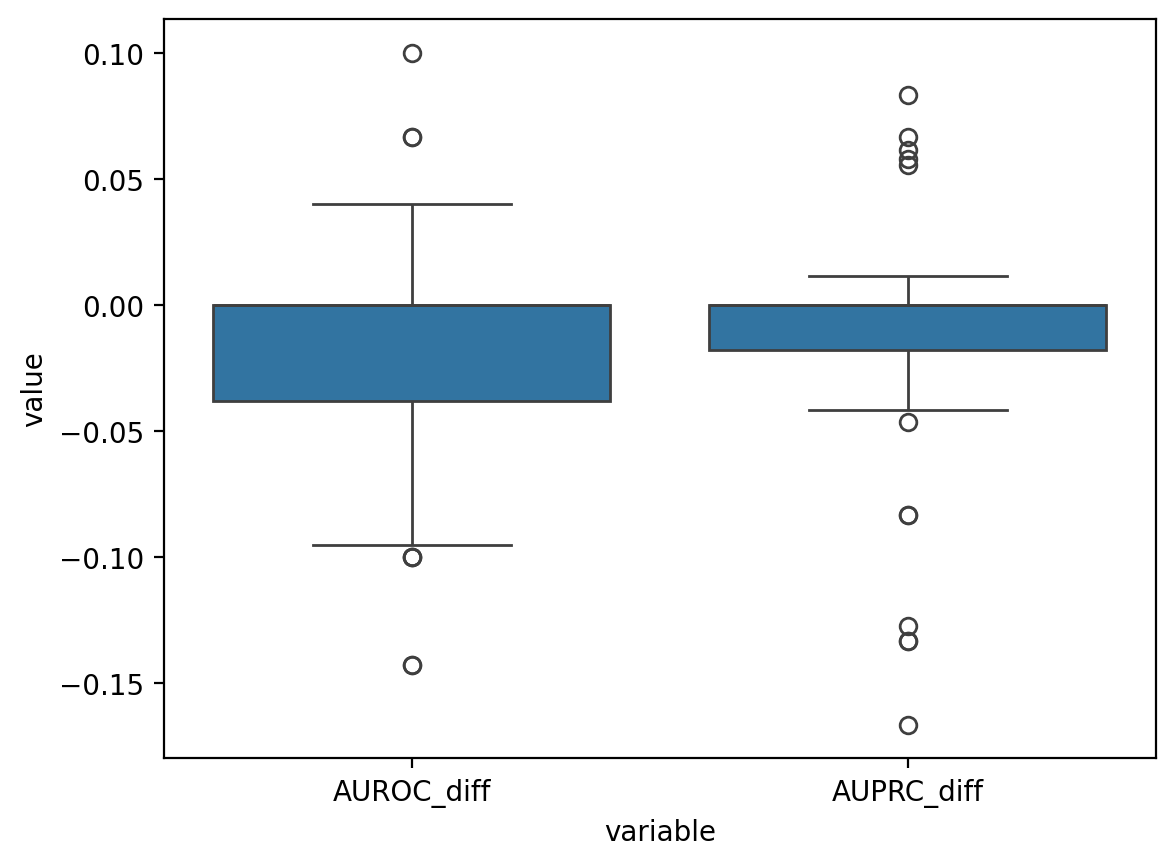

In [40]:
sns.boxplot(
    data=merged_metrics.loc[~merged_metrics.task.str.startswith('H_')].melt(
        id_vars=['task', 'split'],
        value_vars=['AUROC_diff', 'AUPRC_diff']
    ),
    x='variable',
    y='value'
)

In [41]:
merged_metrics[~merged_metrics.task.str.startswith('H_')].agg({'AUROC_diff': 'mean', 'AUPRC_diff': 'mean'})

AUROC_diff   -0.018824
AUPRC_diff   -0.014533
dtype: float64

**Conclusion**: This strategy yields slightly worse results. Also tried without NUPR1+ Macs

### Strategy 2, all cell types, thresholded, equal voice

In [42]:
CELL_TYPE_THRESHOLD = 10

In [43]:
per_sample_data_2 = []
for model_path, model_df in model_perf.items():
    for sample in model_df['sample'].unique():
        cell_type_pred = []
        true_label = None
        for cell_type in model_df.cell_types.unique():
            idx = model_df['sample'].eq(sample) & model_df.cell_types.eq(cell_type)
            if idx.sum() < CELL_TYPE_THRESHOLD:
                continue
            assert model_df.true_label[idx].std() == 0
            cell_type_pred.append(model_df.pred_label[idx].mean())
            true_label = model_df.true_label[idx].iloc[0]

        sample_info = dict(
            model_path=model_path,
            sample=sample,
            n_cells=n_cells,
            avg_pred=np.mean(cell_type_pred),
            true_label=true_label
        )
        per_sample_data_2.append(sample_info)
per_sample_data_2 = pd.DataFrame(per_sample_data_2)

In [44]:
per_sample_data_2['model'] = per_sample_data_2.model_path.str.split('/').str[-1]
per_sample_data_2['split'] = per_sample_data_2.model_path.str.split('/').str[-2]
per_sample_data_2['task'] = per_sample_data_2.model_path.str.split('/').str[-3]
per_sample_data_2 = per_sample_data_2.drop(columns='model_path')

Check that number of cells is equal for different random initializations

In [45]:
assert np.all(per_sample_data_2.groupby(['sample', 'split', 'task']).n_cells.std() == 0)

Take average across random initializations

In [46]:
per_sample_data_agg_2 = per_sample_data_2.groupby(['sample', 'split', 'task']).mean().reset_index()

/tmp/ipykernel_3295531/481172893.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_sample_data_agg_2 = per_sample_data_2.groupby(['sample', 'split', 'task']).mean().reset_index()


In [47]:
per_sample_data_agg_2['pred_label'] = (per_sample_data_agg_2.avg_pred > 0.5).astype(int)

In [48]:
per_sample_metrics_2 = []
for task in per_sample_data_agg_2.task.unique():
    for split in per_sample_data_agg_2.split.unique():
        idx = per_sample_data_agg_2.task.eq(task) & per_sample_data_agg_2.split.eq(split)
        info = compute_metrics(
            per_sample_data_agg_2.avg_pred[idx],
            per_sample_data_agg_2.pred_label[idx],
            per_sample_data_agg_2.true_label[idx]
        )
        info['task'] = task
        info['split'] = split
        per_sample_metrics_2.append(info)

per_sample_metrics_2 = pd.DataFrame(per_sample_metrics_2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [49]:
merged_metrics = per_sample_metrics_2.merge(
    per_sample_metrics,
    on=['task', 'split'],
    suffixes=('_selected', '_all')
)

In [50]:
merged_metrics['AUROC_diff'] = merged_metrics.AUROC_selected - merged_metrics.AUROC_all
merged_metrics['AUPRC_diff'] = merged_metrics.AUPRC_selected - merged_metrics.AUPRC_all

<Axes: xlabel='variable', ylabel='value'>

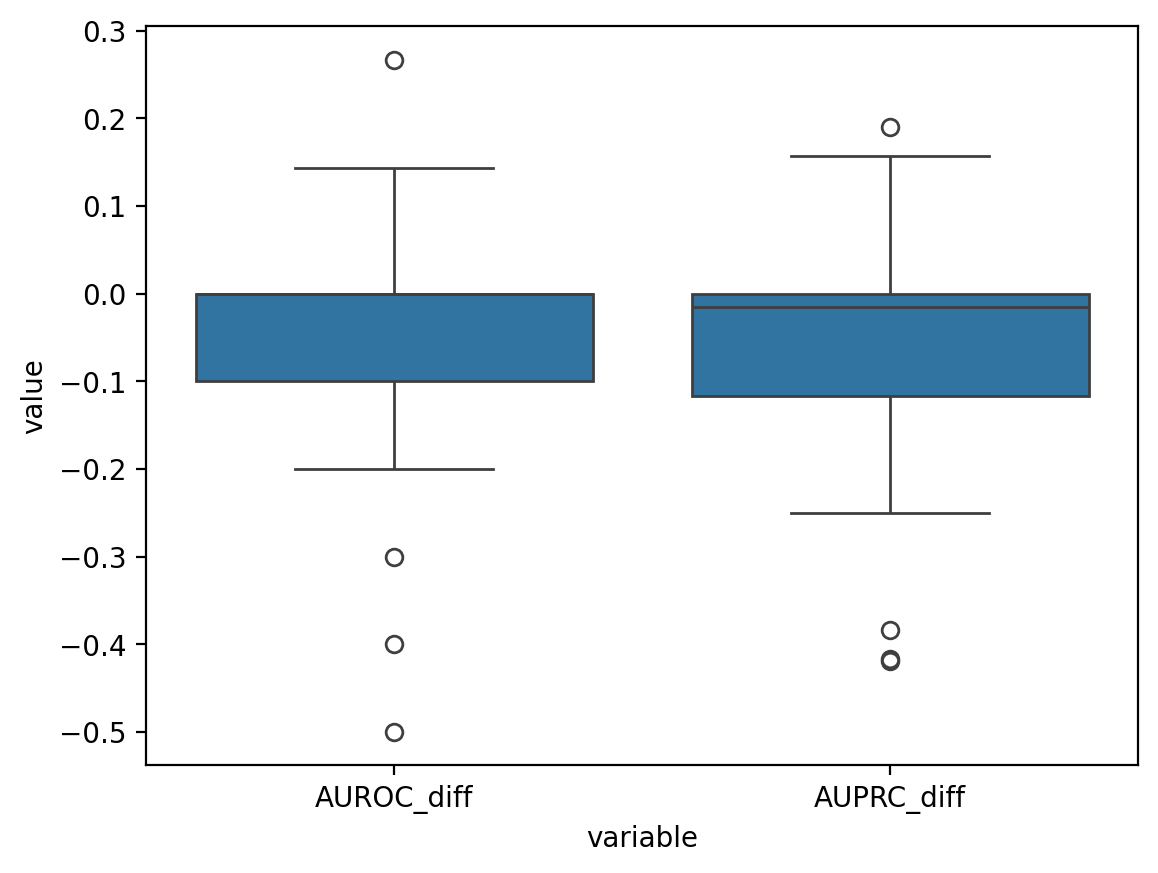

In [51]:
sns.boxplot(
    data=merged_metrics.loc[~merged_metrics.task.str.startswith('H_')].melt(
        id_vars=['task', 'split'],
        value_vars=['AUROC_diff', 'AUPRC_diff']
    ),
    x='variable',
    y='value'
)

In [52]:
merged_metrics.loc[~merged_metrics.task.str.startswith('H_')].agg({'AUROC_diff': 'mean', 'AUPRC_diff': 'mean'})

AUROC_diff   -0.041853
AUPRC_diff   -0.058827
dtype: float64

**Conclusion**: This strategy yields somewhat worse results

### Strategy 3, selected cell types, thresholded, equal voice

In [53]:
per_sample_data_2 = []
for model_path, model_df in model_perf.items():
    for sample in model_df['sample'].unique():
        cell_type_pred = []
        true_label = None
        for cell_type in CELL_TYPES_TO_VOTE:
            idx = model_df['sample'].eq(sample) & model_df.cell_types.eq(cell_type)
            if idx.sum() < CELL_TYPE_THRESHOLD:
                continue
            assert model_df.true_label[idx].std() == 0
            cell_type_pred.append(model_df.pred_label[idx].mean())
            true_label = model_df.true_label[idx].iloc[0]

        sample_info = dict(
            model_path=model_path,
            sample=sample,
            n_cells=n_cells,
            avg_pred=np.mean(cell_type_pred),
            true_label=true_label
        )
        per_sample_data_2.append(sample_info)
per_sample_data_2 = pd.DataFrame(per_sample_data_2)

In [54]:
per_sample_data_2['model'] = per_sample_data_2.model_path.str.split('/').str[-1]
per_sample_data_2['split'] = per_sample_data_2.model_path.str.split('/').str[-2]
per_sample_data_2['task'] = per_sample_data_2.model_path.str.split('/').str[-3]
per_sample_data_2 = per_sample_data_2.drop(columns='model_path')

Check that number of cells is equal for different random initializations

In [55]:
assert np.all(per_sample_data_2.groupby(['sample', 'split', 'task']).n_cells.std() == 0)

Take average across random initializations

In [56]:
per_sample_data_agg_2 = per_sample_data_2.groupby(['sample', 'split', 'task']).mean().reset_index()

/tmp/ipykernel_3295531/481172893.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_sample_data_agg_2 = per_sample_data_2.groupby(['sample', 'split', 'task']).mean().reset_index()


In [57]:
per_sample_data_agg_2['pred_label'] = (per_sample_data_agg_2.avg_pred > 0.5).astype(int)

In [58]:
per_sample_metrics_2 = []
for task in per_sample_data_agg_2.task.unique():
    for split in per_sample_data_agg_2.split.unique():
        idx = per_sample_data_agg_2.task.eq(task) & per_sample_data_agg_2.split.eq(split)
        info = compute_metrics(
            per_sample_data_agg_2.avg_pred[idx],
            per_sample_data_agg_2.pred_label[idx],
            per_sample_data_agg_2.true_label[idx]
        )
        info['task'] = task
        info['split'] = split
        per_sample_metrics_2.append(info)

per_sample_metrics_2 = pd.DataFrame(per_sample_metrics_2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [59]:
merged_metrics = per_sample_metrics_2.merge(
    per_sample_metrics,
    on=['task', 'split'],
    suffixes=('_selected', '_all')
)

In [60]:
merged_metrics['AUROC_diff'] = merged_metrics.AUROC_selected - merged_metrics.AUROC_all
merged_metrics['AUPRC_diff'] = merged_metrics.AUPRC_selected - merged_metrics.AUPRC_all

<Axes: xlabel='variable', ylabel='value'>

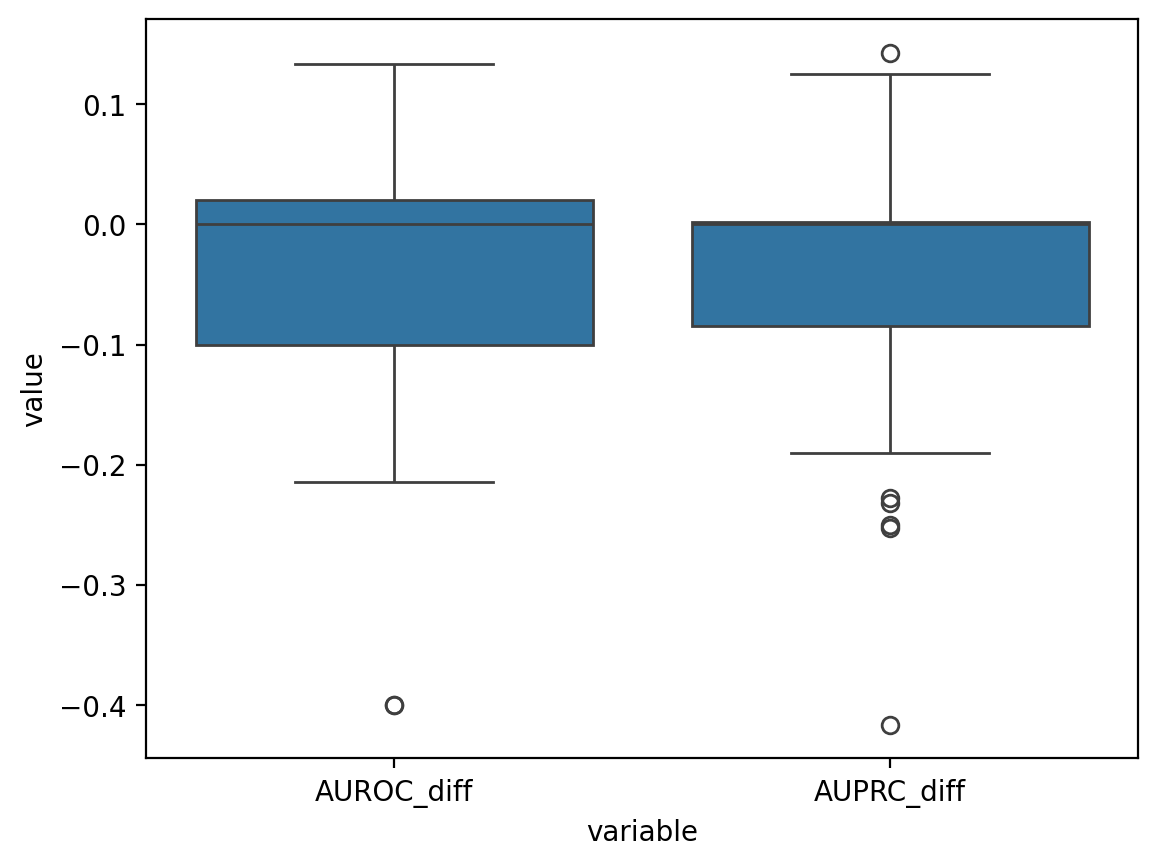

In [61]:
sns.boxplot(
    data=merged_metrics.loc[~merged_metrics.task.str.startswith('H_')].melt(
        id_vars=['task', 'split'],
        value_vars=['AUROC_diff', 'AUPRC_diff']
    ),
    x='variable',
    y='value'
)

In [62]:
merged_metrics.loc[~merged_metrics.task.str.startswith('H_')].agg({'AUROC_diff': 'mean', 'AUPRC_diff': 'mean'})

AUROC_diff   -0.045383
AUPRC_diff   -0.039788
dtype: float64

**Conclusion**: This strategy yields slightly worse results